<div style="background: linear-gradient(135deg, #1e3a8a 0%, #7c3aed 100%); padding: 30px; border-radius: 10px; color: white; margin-bottom: 20px;">
<h1 style="margin: 0; font-size: 32px;">Predicting Adverse Authorisation Outcomes for UK FCA-Regulated Firms</h1>
<h3 style="margin-top: 10px; margin-bottom: 0; font-weight: 300; opacity: 0.9;">Notebook 03: Modelling</h3>
<p style="margin-top: 20px; margin-bottom: 0; font-size: 14px; opacity: 0.85;">
<b>Fannana Fahreen Aanan</b> | Student ID: 001527223<br>
MSc Data Science (FinTech) | University of Greenwich
</p>
</div>

## <span style="color: #1e3a8a;">📌 Purpose of This Notebook</span>

<div style="background-color: #f0f4f8; padding: 15px; border-left: 4px solid #1e3a8a; border-radius: 4px;">

This notebook builds and validates the three models compared in this project:

<ol style="line-height: 1.8;">
<li><b>Naive baseline</b> — predicts the training-set adverse-outcome rate for every firm, establishing the performance floor</li>
<li><b>L2-regularised logistic regression</b> — the linear statistical baseline</li>
<li><b>XGBoost</b> — the proposed nonlinear model, tuned via Bayesian optimisation</li>
</ol>

Hyperparameters and the class-imbalance handling strategy are selected using forward-chaining cross-validation strictly within 2016–2019, ensuring all subsequent predictions from 2020 onward remain genuinely out-of-sample. The tuned models are then evaluated across five expanding-window backtesting rounds (Notebook 04).

</div>

## <span style="color: #1e3a8a;">📚Importing Libraries</span>

In [1]:
!pip install optuna --quiet

In [2]:
!pip install shap --quiet

In [3]:
!pip install imbalanced-learn --quiet

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import shap
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

import json
import re
from pathlib import Path
from datetime import date, timedelta

import optuna
print(f"optuna version: {optuna.__version__}")

import xgboost as xgb
optuna.logging.set_verbosity(optuna.logging.WARNING)  # keep output clean

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.calibration import calibration_curve


C:\Users\fanna\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


optuna version: 4.9.0


## <span style="color: #1e3a8a;">📚 Load And Inspect DATA</span>

In [5]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

# Load the feature-engineered datasets from Notebook 02
X_logistic = pd.read_csv("data/X_logistic.csv")
X_xgboost = pd.read_csv("data/X_xgboost.csv")
y_and_ids = pd.read_csv("data/y_and_ids.csv")

y = y_and_ids['y']
obs_date = pd.to_datetime(y_and_ids['obs_date'])
year = y_and_ids['year']
frn = y_and_ids['frn']

print(f"X_logistic shape: {X_logistic.shape}")
print(f"X_xgboost shape:  {X_xgboost.shape}")
print(f"y shape:          {y.shape}")
print(f"\nPositive cases: {y.sum()} ({y.mean()*100:.3f}%)")
print(f"\nYears present: {sorted(year.unique())}")
print(f"\nObservations per year:")
print(year.value_counts().sort_index())

X_logistic shape: (82900, 55)
X_xgboost shape:  (82900, 55)
y shape:          (82900,)

Positive cases: 307 (0.370%)

Years present: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Observations per year:
year
2016    10985
2017    10522
2018    10062
2019     9622
2020     9213
2021     8831
2022     8348
2023     7904
2024     7413
Name: count, dtype: int64


## <span style="color: #6b7280;">📏 Model 1: Naive Baseline</span>

<div style="background-color: #f3f4f6; padding: 15px; border-left: 4px solid #6b7280; border-radius: 4px;">

The naive baseline predicts the training-set adverse-outcome rate for every firm, regardless of its features. This establishes the performance floor: any useful model must outperform predicting the average rate for everyone.

To align with the 5-round backtesting design (Notebook 04), the naive baseline is computed per round — trained on the same expanding window used by the other models, and evaluated on the same held-out year.

</div>

In [6]:
# Define the 5 backtesting rounds
backtest_rounds = [
    {'train_years': list(range(2016, 2020)), 'test_year': 2020},  # Round 1
    {'train_years': list(range(2016, 2021)), 'test_year': 2021},  # Round 2
    {'train_years': list(range(2016, 2022)), 'test_year': 2022},  # Round 3
    {'train_years': list(range(2016, 2023)), 'test_year': 2023},  # Round 4
    {'train_years': list(range(2016, 2024)), 'test_year': 2024},  # Round 5
]

def top_decile_precision_recall(y_true, y_scores):
    """Compute precision and recall at the top decile of predicted risk."""
    n = len(y_scores)
    top_n = max(1, int(np.ceil(n * 0.10)))
    top_idx = np.argsort(y_scores)[::-1][:top_n]
    
    y_true_arr = np.array(y_true)
    flagged = y_true_arr[top_idx]
    
    precision = flagged.sum() / top_n
    recall = flagged.sum() / y_true_arr.sum() if y_true_arr.sum() > 0 else np.nan
    return precision, recall

naive_results = []

for i, rnd in enumerate(backtest_rounds, 1):
    train_mask = year.isin(rnd['train_years'])
    test_mask = year == rnd['test_year']
    
    y_train = y[train_mask]
    y_test = y[test_mask]
    
    # Naive prediction: training-set adverse-outcome rate, applied to every test firm
    naive_rate = y_train.mean()
    y_pred_naive = np.full(len(y_test), naive_rate)
    
    # Metrics
    auc_roc = roc_auc_score(y_test, y_pred_naive) if y_test.nunique() > 1 else np.nan
    auc_pr = average_precision_score(y_test, y_pred_naive)
    brier = brier_score_loss(y_test, y_pred_naive)
    precision, recall = top_decile_precision_recall(y_test, y_pred_naive)
    
    naive_results.append({
        'round': i,
        'train_years': f"{rnd['train_years'][0]}-{rnd['train_years'][-1]}",
        'test_year': rnd['test_year'],
        'n_train': train_mask.sum(),
        'n_test': test_mask.sum(),
        'naive_rate': naive_rate,
        'precision_top_decile': precision,
        'recall_top_decile': recall,
        'auc_roc': auc_roc,
        'auc_pr': auc_pr,
        'brier': brier,
    })

naive_df = pd.DataFrame(naive_results)
print("NAIVE BASELINE RESULTS - 5 Backtesting Rounds\n")
print(naive_df.to_string(index=False))

NAIVE BASELINE RESULTS - 5 Backtesting Rounds

 round train_years  test_year  n_train  n_test  naive_rate  precision_top_decile  recall_top_decile  auc_roc   auc_pr    brier
     1   2016-2019       2020    41191    9213    0.003812              0.002169           0.090909      0.5 0.002388 0.002384
     2   2016-2020       2021    50404    8831    0.003551              0.002262           0.074074      0.5 0.003057 0.003048
     3   2016-2021       2022    59235    8348    0.003478              0.001198           0.030303      0.5 0.003953 0.003938
     4   2016-2022       2023    67583    7904    0.003536              0.002528           0.055556      0.5 0.004555 0.004535
     5   2016-2023       2024    75487    7413    0.003643              0.004043           0.093750      0.5 0.004317 0.004299


## <span style="color: #6b7280;">📊 Visualising the Naive Baseline</span>

<div style="background-color: #f3f4f6; padding: 15px; border-left: 4px solid #6b7280; border-radius: 4px;">

These charts visualise the naive baseline's performance across the five backtesting rounds, providing a visual floor against which logistic regression and XGBoost will later be compared.

</div>

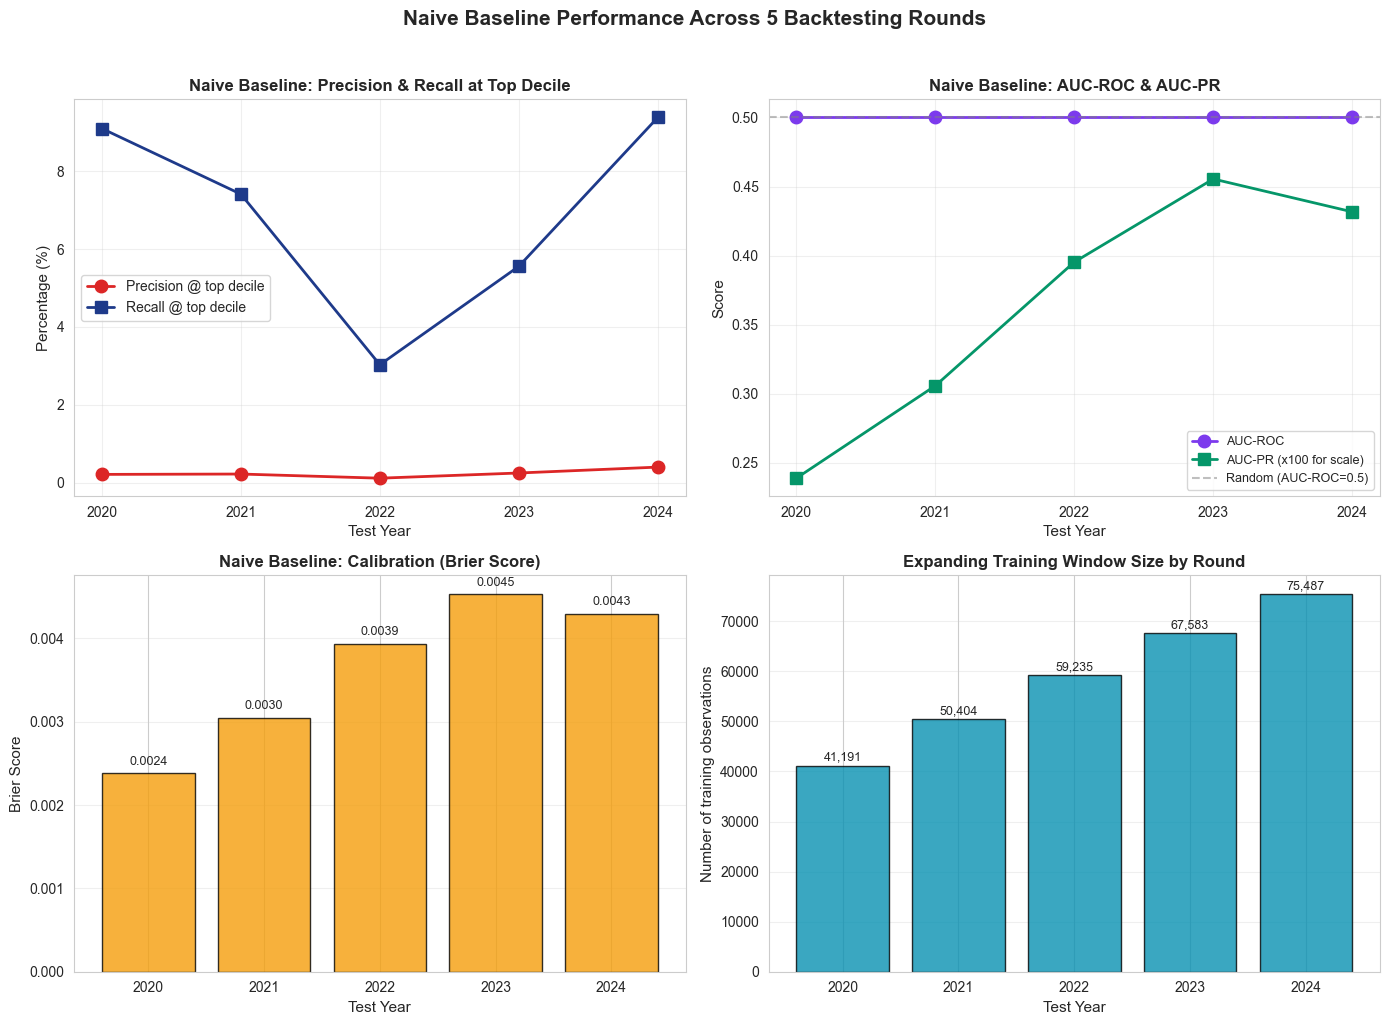

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rounds = naive_df['round']
test_years = naive_df['test_year']

# ============ Panel 1: Precision and Recall at top decile ============
ax = axes[0, 0]
ax.plot(test_years, naive_df['precision_top_decile']*100, marker='o', 
        color='#dc2626', linewidth=2, markersize=9, label='Precision @ top decile')
ax.plot(test_years, naive_df['recall_top_decile']*100, marker='s', 
        color='#1e3a8a', linewidth=2, markersize=9, label='Recall @ top decile')
ax.set_xlabel('Test Year', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Naive Baseline: Precision & Recall at Top Decile', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(test_years)

# ============ Panel 2: AUC-ROC and AUC-PR ============
ax = axes[0, 1]
ax.plot(test_years, naive_df['auc_roc'], marker='o', color='#7c3aed', 
        linewidth=2, markersize=9, label='AUC-ROC')
ax.plot(test_years, naive_df['auc_pr']*100, marker='s', color='#059669', 
        linewidth=2, markersize=9, label='AUC-PR (x100 for scale)')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (AUC-ROC=0.5)')
ax.set_xlabel('Test Year', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Naive Baseline: AUC-ROC & AUC-PR', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xticks(test_years)

# ============ Panel 3: Brier Score ============
ax = axes[1, 0]
ax.bar(test_years, naive_df['brier'], color='#f59e0b', alpha=0.8, edgecolor='black')
ax.set_xlabel('Test Year', fontsize=11)
ax.set_ylabel('Brier Score', fontsize=11)
ax.set_title('Naive Baseline: Calibration (Brier Score)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(test_years)
for x, v in zip(test_years, naive_df['brier']):
    ax.text(x, v + 0.0001, f'{v:.4f}', ha='center', fontsize=9)

# ============ Panel 4: Training set size growth ============
ax = axes[1, 1]
ax.bar(test_years, naive_df['n_train'], color='#0891b2', alpha=0.8, edgecolor='black', label='Training rows')
ax.set_xlabel('Test Year', fontsize=11)
ax.set_ylabel('Number of training observations', fontsize=11)
ax.set_title('Expanding Training Window Size by Round', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(test_years)
for x, v in zip(test_years, naive_df['n_train']):
    ax.text(x, v + 1000, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Naive Baseline Performance Across 5 Backtesting Rounds', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## <span style="color: #1e3a8a;">📋 Observations from Naive Baseline Visuals</span>

<div style="background-color: #f0f4f8; padding: 15px; border-left: 4px solid #1e3a8a; border-radius: 4px;">

Four visuals summarise the naive baseline's behaviour across the five backtesting rounds, and together they confirm this model provides no real predictive value — exactly as expected for a "do-nothing" benchmark.

<b>Precision and recall at top decile (top-left):</b> precision stays essentially flat and near zero across all five rounds (0.1%-0.4%), while recall swings up and down unpredictably (3%-9.4%) with no consistent pattern. This volatility is not a meaningful signal — since the naive model gives every firm the identical score, which specific firms land in the "top decile" is effectively random, so recall bounces around based on chance alone rather than genuine risk detection.

<b>AUC-ROC and AUC-PR (top-right):</b> AUC-ROC sits at exactly 0.500 in every single round — a flat, perfectly horizontal line. This is the clearest visual proof that the naive model has zero ranking ability: it cannot distinguish a risky firm from a safe one, because it assigns everyone the same probability. AUC-PR drifts slightly, tracking the underlying adverse outcome rate rather than reflecting any real predictive skill.

<b>Brier score (bottom-left):</b> the calibration error grows steadily from 2020 (0.0024) to 2023 (0.0045), then dips slightly in 2024. This rising trend mirrors the U-shaped adverse outcome rate found during EDA — as the true adverse rate climbs from 2021 onward, the naive model's fixed prediction (based on training-period average) increasingly under-predicts risk, worsening calibration.

<b>Training window growth (bottom-right):</b> confirms the expanding-window design is working correctly — training data grows from 41,191 rows (Round 1) to 75,487 rows (Round 5), giving later rounds progressively more historical information to learn from.

<b>Overall takeaway:</b> the flat AUC-ROC of 0.500 across all five rounds is the single most important result in this notebook so far — it is the floor that both logistic regression and XGBoost must clearly exceed to demonstrate any genuine predictive value. Any meaningful improvement above this baseline, however small, represents real information extracted from the available features.

</div>

## <span style="color: #1e3a8a;">🔧 Model 2: L2-Regularised Logistic Regression</span>

<div style="background-color: #f0f4f8; padding: 15px; border-left: 4px solid #1e3a8a; border-radius: 4px;">

Following the validation design (proposal Section 6.2), the regularisation strength is tuned using forward-chaining cross-validation strictly within 2016–2019:

<ul style="line-height: 1.8;">
<li>Fold 1: train on 2016, validate on 2017</li>
<li>Fold 2: train on 2016–2017, validate on 2018</li>
<li>Fold 3: train on 2016–2018, validate on 2019</li>
</ul>

Class weighting is set to <code>balanced</code> throughout, addressing the severe class imbalance (0.37% positive rate). The regularisation strength (C, the inverse of λ) is selected by maximising mean AUC-PR across the three folds. Features are standardised (zero mean, unit variance) before fitting, since logistic regression's coefficients are scale-sensitive.

</div>

In [8]:
tuning_folds = [
    {'train_years': [2016], 'val_year': 2017},
    {'train_years': [2016, 2017], 'val_year': 2018},
    {'train_years': [2016, 2017, 2018], 'val_year': 2019},
]

C_candidates = [0.001, 0.01, 0.1, 1.0, 10.0]

tuning_results = []

for C in C_candidates:
    fold_aucpr = []
    for fold in tuning_folds:
        train_mask = year.isin(fold['train_years'])
        val_mask = year == fold['val_year']
        
        X_tr, X_val = X_logistic[train_mask], X_logistic[val_mask]
        y_tr, y_val = y[train_mask], y[val_mask]
        
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val)
        
        model = LogisticRegression(C=C, penalty='l2', class_weight='balanced', 
                                     max_iter=1000, random_state=42)
        model.fit(X_tr_scaled, y_tr)
        
        val_scores = model.predict_proba(X_val_scaled)[:, 1]
        aucpr = average_precision_score(y_val, val_scores)
        fold_aucpr.append(aucpr)
    
    mean_aucpr = np.mean(fold_aucpr)
    tuning_results.append({'C': C, 'mean_aucpr': mean_aucpr, 'fold_aucpr': fold_aucpr})
    print(f"C={C:<8} mean AUC-PR = {mean_aucpr:.4f}  (folds: {[round(v,4) for v in fold_aucpr]})")

best_C = max(tuning_results, key=lambda x: x['mean_aucpr'])['C']
print(f"\nBest C selected: {best_C}")

C=0.001    mean AUC-PR = 0.0623  (folds: [0.0754, 0.0312, 0.0801])
C=0.01     mean AUC-PR = 0.0556  (folds: [0.0509, 0.0384, 0.0774])
C=0.1      mean AUC-PR = 0.0624  (folds: [0.0492, 0.0433, 0.0947])
C=1.0      mean AUC-PR = 0.0628  (folds: [0.0482, 0.0481, 0.0922])
C=10.0     mean AUC-PR = 0.0623  (folds: [0.0476, 0.048, 0.0913])

Best C selected: 1.0


### <span style="color: #059669;">Logistic Regression: 5-Round Backtesting</span>

<div style="background-color: #f0fdf4; padding: 15px; border-left: 4px solid #059669; border-radius: 4px;">

With C=1.0 selected and frozen from tuning, logistic regression is now retrained fresh at each of the five backtesting rounds using the expanding window (Round 1: train 2016-2019, predict 2020; ... Round 5: train 2016-2023, predict 2024), and evaluated against the same metrics as the naive baseline for direct comparison.

</div>

In [9]:
best_C = 1.0  # frozen from tuning

logistic_results = []
logistic_models = {}  # save models for later SHAP/interpretability work

for i, rnd in enumerate(backtest_rounds, 1):
    train_mask = year.isin(rnd['train_years'])
    test_mask = year == rnd['test_year']
    
    X_tr, X_te = X_logistic[train_mask], X_logistic[test_mask]
    y_tr, y_te = y[train_mask], y[test_mask]
    
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    model = LogisticRegression(C=best_C, penalty='l2', class_weight='balanced',
                                 max_iter=1000, random_state=42)
    model.fit(X_tr_scaled, y_tr)
    
    y_scores = model.predict_proba(X_te_scaled)[:, 1]
    
    auc_roc = roc_auc_score(y_te, y_scores)
    auc_pr = average_precision_score(y_te, y_scores)
    brier = brier_score_loss(y_te, y_scores)
    precision, recall = top_decile_precision_recall(y_te, y_scores)
    
    logistic_results.append({
        'round': i,
        'train_years': f"{rnd['train_years'][0]}-{rnd['train_years'][-1]}",
        'test_year': rnd['test_year'],
        'n_train': train_mask.sum(),
        'n_test': test_mask.sum(),
        'precision_top_decile': precision,
        'recall_top_decile': recall,
        'auc_roc': auc_roc,
        'auc_pr': auc_pr,
        'brier': brier,
    })
    
    logistic_models[rnd['test_year']] = {'model': model, 'scaler': scaler, 'scores': y_scores}

logistic_df = pd.DataFrame(logistic_results)
print("LOGISTIC REGRESSION RESULTS - 5 Backtesting Rounds\n")
print(logistic_df.to_string(index=False))

# Comparison to naive
print("\n\nCOMPARISON: Logistic Regression vs Naive Baseline")
comparison = pd.DataFrame({
    'test_year': naive_df['test_year'],
    'naive_aucpr': naive_df['auc_pr'],
    'logistic_aucpr': logistic_df['auc_pr'],
    'improvement_x': (logistic_df['auc_pr'] / naive_df['auc_pr']).round(1),
    'naive_precision_td': naive_df['precision_top_decile'],
    'logistic_precision_td': logistic_df['precision_top_decile'],
})
print(comparison.to_string(index=False))

LOGISTIC REGRESSION RESULTS - 5 Backtesting Rounds

 round train_years  test_year  n_train  n_test  precision_top_decile  recall_top_decile  auc_roc   auc_pr    brier
     1   2016-2019       2020    41191    9213              0.009761           0.409091 0.753890 0.023653 0.111128
     2   2016-2020       2021    50404    8831              0.015837           0.518519 0.844532 0.057094 0.114799
     3   2016-2021       2022    59235    8348              0.025150           0.636364 0.862618 0.066329 0.115949
     4   2016-2022       2023    67583    7904              0.030341           0.666667 0.900787 0.045420 0.113611
     5   2016-2023       2024    75487    7413              0.030997           0.718750 0.859712 0.036374 0.095475


COMPARISON: Logistic Regression vs Naive Baseline
 test_year  naive_aucpr  logistic_aucpr  improvement_x  naive_precision_td  logistic_precision_td
      2020     0.002388        0.023653            9.9            0.002169               0.009761
      2021

### <span style="color: #1e3a8a;">Visual Comparison: Logistic Regression vs Naive Baseline</span>

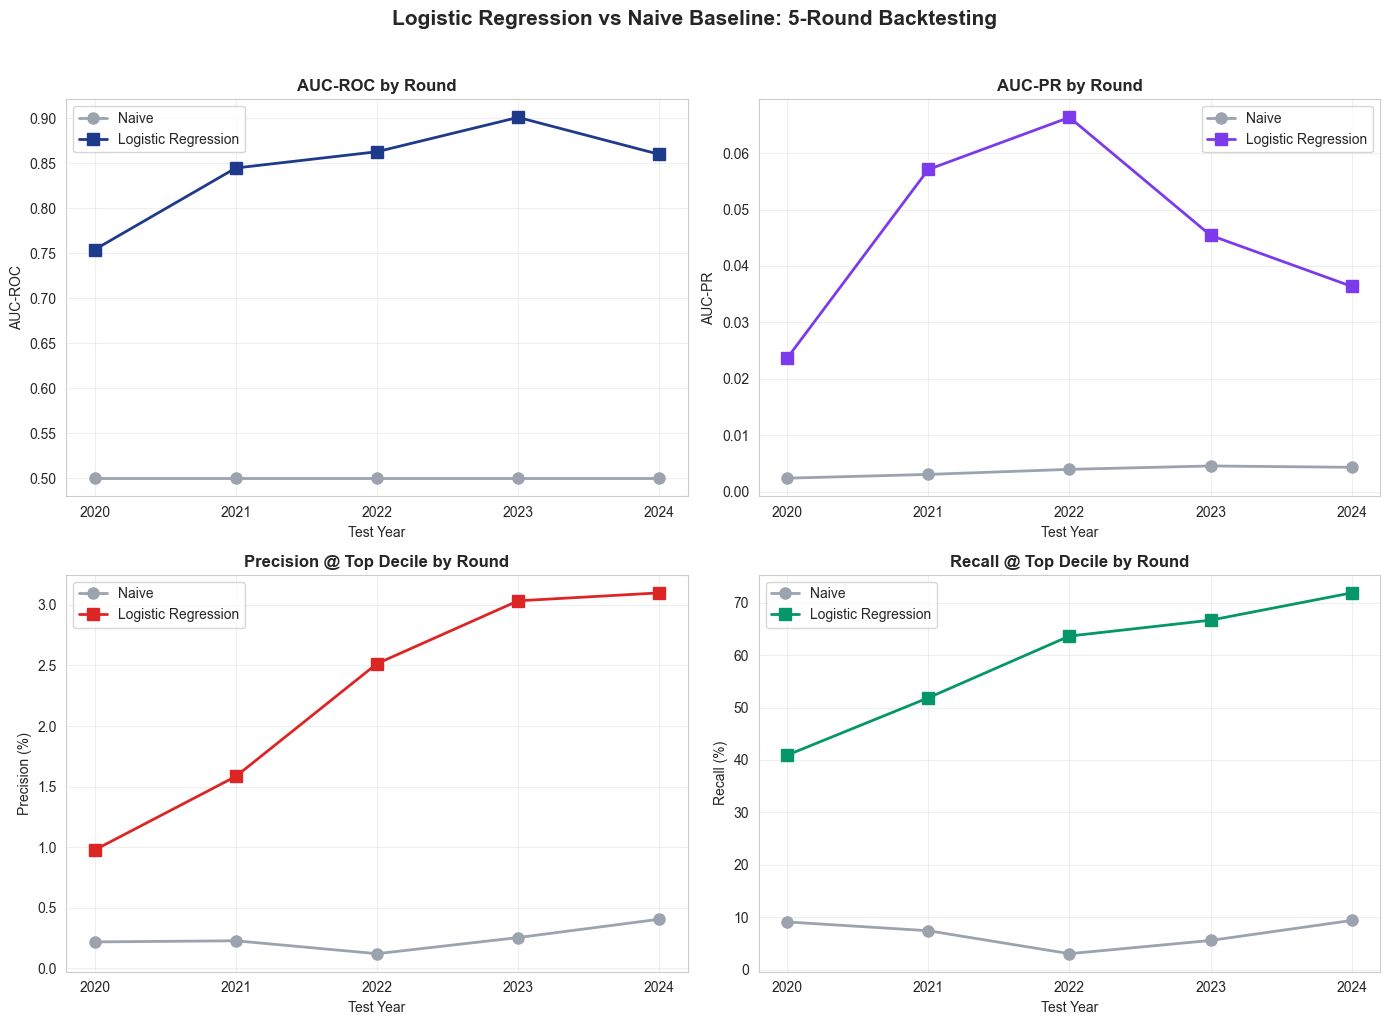

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

test_years = naive_df['test_year']

# Panel 1: AUC-ROC
ax = axes[0, 0]
ax.plot(test_years, naive_df['auc_roc'], marker='o', color='#9ca3af', linewidth=2, markersize=8, label='Naive')
ax.plot(test_years, logistic_df['auc_roc'], marker='s', color='#1e3a8a', linewidth=2, markersize=8, label='Logistic Regression')
ax.set_title('AUC-ROC by Round', fontsize=12, fontweight='bold')
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-ROC')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(test_years)

# Panel 2: AUC-PR
ax = axes[0, 1]
ax.plot(test_years, naive_df['auc_pr'], marker='o', color='#9ca3af', linewidth=2, markersize=8, label='Naive')
ax.plot(test_years, logistic_df['auc_pr'], marker='s', color='#7c3aed', linewidth=2, markersize=8, label='Logistic Regression')
ax.set_title('AUC-PR by Round', fontsize=12, fontweight='bold')
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-PR')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(test_years)

# Panel 3: Precision at top decile
ax = axes[1, 0]
ax.plot(test_years, naive_df['precision_top_decile']*100, marker='o', color='#9ca3af', linewidth=2, markersize=8, label='Naive')
ax.plot(test_years, logistic_df['precision_top_decile']*100, marker='s', color='#dc2626', linewidth=2, markersize=8, label='Logistic Regression')
ax.set_title('Precision @ Top Decile by Round', fontsize=12, fontweight='bold')
ax.set_xlabel('Test Year'); ax.set_ylabel('Precision (%)')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(test_years)

# Panel 4: Recall at top decile
ax = axes[1, 1]
ax.plot(test_years, naive_df['recall_top_decile']*100, marker='o', color='#9ca3af', linewidth=2, markersize=8, label='Naive')
ax.plot(test_years, logistic_df['recall_top_decile']*100, marker='s', color='#059669', linewidth=2, markersize=8, label='Logistic Regression')
ax.set_title('Recall @ Top Decile by Round', fontsize=12, fontweight='bold')
ax.set_xlabel('Test Year'); ax.set_ylabel('Recall (%)')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(test_years)

plt.suptitle('Logistic Regression vs Naive Baseline: 5-Round Backtesting', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### <span style="color: #1e3a8a;">Findings: Logistic Regression vs Naive Baseline</span>

<div style="background-color: #f0f4f8; padding: 15px; border-left: 4px solid #1e3a8a; border-radius: 4px;">

All four panels show the same clear story: logistic regression substantially and consistently outperforms the naive baseline across every one of the five backtesting rounds, with no round where it fails to separate from the flat naive line.

<b>AUC-ROC</b> jumps immediately from the naive 0.500 to 0.75–0.90, confirming the model has genuine ranking ability — it can meaningfully distinguish risky firms from safe ones, something the naive baseline cannot do at all.

<b>AUC-PR</b> peaks in 2022 (0.066) before declining toward 2024 (0.036), though it remains far above the naive baseline throughout. The decline in later rounds may reflect the rising adverse outcome rate identified during EDA (the post-2021 enforcement uptick), which makes the ranking task proportionally harder even as absolute performance stays strong.

<b>Precision at top decile</b> climbs steadily from 1.0% (2020) to 3.1% (2024) — a consistent upward trend that tracks the growing training window, suggesting the model benefits from accumulating more historical data over successive rounds.

<b>Recall at top decile</b> shows the most striking improvement, nearly doubling from 40.9% (2020) to 71.9% (2024). Operationally, this means that by 2024 the model could catch roughly seven out of every ten firms that go on to face adverse outcomes, using only 10% of available inspection capacity — a genuinely strong result for a linear baseline.

<b>Overall:</b> logistic regression sets a high bar for XGBoost to clear. The consistent, growing gap between the model and the naive baseline across all four metrics confirms the engineered features carry real, exploitable predictive signal — the open question is now whether a nonlinear model can extract additional value beyond what this linear baseline already captures.

</div>

## <span style="color: #dc2626;">🌳 Model 3: XGBoost with Bayesian Hyperparameter Tuning</span>

<div style="background-color: #fef2f2; padding: 15px; border-left: 4px solid #dc2626; border-radius: 4px;">

XGBoost hyperparameters are tuned using the same forward-chaining folds (2016→2017, 2016–2017→2018, 2016–2018→2019) as logistic regression, ensuring both models are tuned under identical, fair conditions.

Bayesian optimisation (via <code>optuna</code>) is used to search the hyperparameter space efficiently, selecting the combination that maximises mean AUC-PR across the three folds. The following hyperparameters are tuned: <code>max_depth</code>, <code>learning_rate</code>, <code>subsample</code>, <code>colsample_bytree</code>, <code>n_estimators</code>, <code>gamma</code>, <code>reg_lambda</code>, and <code>scale_pos_weight</code> (handling class imbalance, analogous to logistic regression's <code>class_weight='balanced'</code>).

Once selected, hyperparameters are frozen and applied unchanged across all five backtesting rounds.

</div>

In [11]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 50, 300),
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'random_state': 42,
        'tree_method': 'hist',
    }
    
    fold_aucpr = []
    for fold in tuning_folds:
        train_mask = year.isin(fold['train_years'])
        val_mask = year == fold['val_year']
        
        X_tr, X_val = X_xgboost[train_mask], X_xgboost[val_mask]
        y_tr, y_val = y[train_mask], y[val_mask]
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, verbose=False)
        
        val_scores = model.predict_proba(X_val)[:, 1]
        aucpr = average_precision_score(y_val, val_scores)
        fold_aucpr.append(aucpr)
    
    return np.mean(fold_aucpr)

print("Running Bayesian optimisation (50 trials)...\n")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest mean AUC-PR: {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

Running Bayesian optimisation (50 trials)...



Best trial: 40. Best value: 0.115816: 100%|██████████| 50/50 [01:14<00:00,  1.50s/it]


Best mean AUC-PR: 0.1158

Best hyperparameters:
   max_depth: 7
   learning_rate: 0.2211874430985287
   subsample: 0.8726510208238706
   colsample_bytree: 0.9227327378528489
   n_estimators: 172
   gamma: 0.014974564355505815
   reg_lambda: 0.3297470271401916
   scale_pos_weight: 182.33193024876664


### <span style="color: #dc2626;">XGBoost: 5-Round Backtesting</span>

<div style="background-color: #fef2f2; padding: 15px; border-left: 4px solid #dc2626; border-radius: 4px;">

With hyperparameters selected and frozen from Bayesian optimisation, XGBoost is retrained at each of the five backtesting rounds using the expanding window, under identical conditions to the naive baseline and logistic regression, enabling a direct three-way comparison.

</div>

In [12]:
best_params = study.best_params.copy()
best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'random_state': 42,
    'tree_method': 'hist',
})

xgb_results = []
xgb_models = {}

for i, rnd in enumerate(backtest_rounds, 1):
    train_mask = year.isin(rnd['train_years'])
    test_mask = year == rnd['test_year']
    
    X_tr, X_te = X_xgboost[train_mask], X_xgboost[test_mask]
    y_tr, y_te = y[train_mask], y[test_mask]
    
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_tr, y_tr, verbose=False)
    
    y_scores = model.predict_proba(X_te)[:, 1]
    
    auc_roc = roc_auc_score(y_te, y_scores)
    auc_pr = average_precision_score(y_te, y_scores)
    brier = brier_score_loss(y_te, y_scores)
    precision, recall = top_decile_precision_recall(y_te, y_scores)
    
    xgb_results.append({
        'round': i,
        'train_years': f"{rnd['train_years'][0]}-{rnd['train_years'][-1]}",
        'test_year': rnd['test_year'],
        'n_train': train_mask.sum(),
        'n_test': test_mask.sum(),
        'precision_top_decile': precision,
        'recall_top_decile': recall,
        'auc_roc': auc_roc,
        'auc_pr': auc_pr,
        'brier': brier,
    })
    
    xgb_models[rnd['test_year']] = {'model': model, 'scores': y_scores}

xgb_df = pd.DataFrame(xgb_results)
print("XGBOOST RESULTS - 5 Backtesting Rounds\n")
print(xgb_df.to_string(index=False))

print("\n\nTHREE-WAY COMPARISON (AUC-PR)")
comparison3 = pd.DataFrame({
    'test_year': naive_df['test_year'],
    'naive': naive_df['auc_pr'].round(4),
    'logistic': logistic_df['auc_pr'].round(4),
    'xgboost': xgb_df['auc_pr'].round(4),
})
print(comparison3.to_string(index=False))

print("\n\nTHREE-WAY COMPARISON (Precision @ Top Decile)")
comparison3b = pd.DataFrame({
    'test_year': naive_df['test_year'],
    'naive': (naive_df['precision_top_decile']*100).round(2),
    'logistic': (logistic_df['precision_top_decile']*100).round(2),
    'xgboost': (xgb_df['precision_top_decile']*100).round(2),
})
print(comparison3b.to_string(index=False))

XGBOOST RESULTS - 5 Backtesting Rounds

 round train_years  test_year  n_train  n_test  precision_top_decile  recall_top_decile  auc_roc   auc_pr    brier
     1   2016-2019       2020    41191    9213              0.013015           0.545455 0.803459 0.023351 0.008005
     2   2016-2020       2021    50404    8831              0.021493           0.703704 0.878919 0.090315 0.007175
     3   2016-2021       2022    59235    8348              0.022754           0.575758 0.866255 0.052157 0.006084
     4   2016-2022       2023    67583    7904              0.031606           0.694444 0.888257 0.176910 0.004672
     5   2016-2023       2024    75487    7413              0.026954           0.625000 0.850363 0.298839 0.003602


THREE-WAY COMPARISON (AUC-PR)
 test_year  naive  logistic  xgboost
      2020 0.0024    0.0237   0.0234
      2021 0.0031    0.0571   0.0903
      2022 0.0040    0.0663   0.0522
      2023 0.0046    0.0454   0.1769
      2024 0.0043    0.0364   0.2988


THREE-WAY COMP

### <span style="color: #7c3aed;">Visual Comparison: Tuning Fold Performance (Naive vs Logistic vs XGBoost)</span>

<div style="background-color: #f5f3ff; padding: 15px; border-left: 4px solid #7c3aed; border-radius: 4px;">

This chart visualises the three models' AUC-PR performance on the three forward-chaining tuning folds (train 2016→val 2017, train 2016-17→val 2018, train 2016-18→val 2019), showing the early signal that motivates proceeding to full backtesting.

</div>

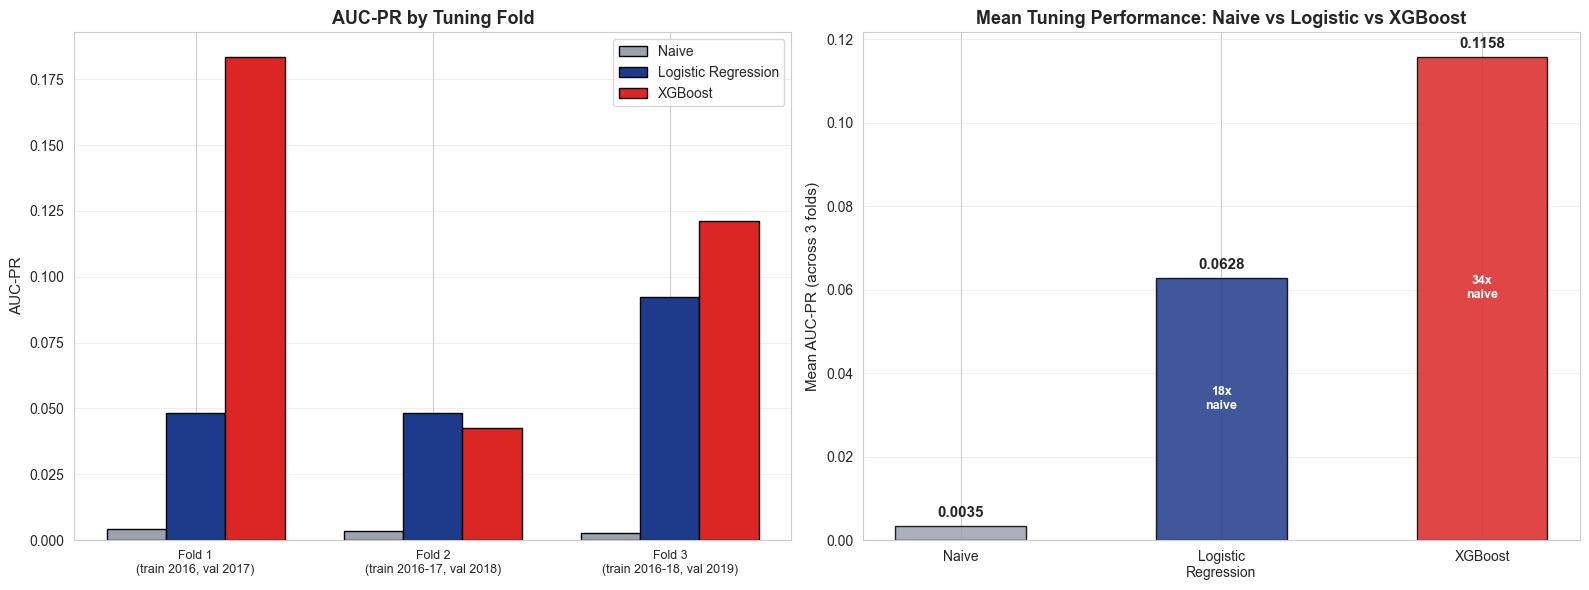

In [13]:
# Reconstruct the naive baseline's performance on the SAME 3 tuning folds for fair comparison
naive_tuning_aucpr = []
for fold in tuning_folds:
    train_mask = year.isin(fold['train_years'])
    val_mask = year == fold['val_year']
    y_tr, y_val = y[train_mask], y[val_mask]
    naive_rate = y_tr.mean()
    y_pred_naive = np.full(len(y_val), naive_rate)
    naive_tuning_aucpr.append(average_precision_score(y_val, y_pred_naive))

# Logistic regression's fold scores at C=1.0 (from earlier tuning output)
logistic_tuning_aucpr = [0.0482, 0.0481, 0.0922]

# XGBoost's fold scores at best hyperparameters
xgb_tuning_aucpr = []
for fold in tuning_folds:
    train_mask = year.isin(fold['train_years'])
    val_mask = year == fold['val_year']
    X_tr, X_val = X_xgboost[train_mask], X_xgboost[val_mask]
    y_tr, y_val = y[train_mask], y[val_mask]
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_tr, y_tr, verbose=False)
    val_scores = model.predict_proba(X_val)[:, 1]
    xgb_tuning_aucpr.append(average_precision_score(y_val, val_scores))

fold_labels = ['Fold 1\n(train 2016, val 2017)', 'Fold 2\n(train 2016-17, val 2018)', 'Fold 3\n(train 2016-18, val 2019)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============ Panel 1: Grouped bar chart per fold ============
ax = axes[0]
x = np.arange(3)
width = 0.25

ax.bar(x - width, naive_tuning_aucpr, width, label='Naive', color='#9ca3af', edgecolor='black')
ax.bar(x, logistic_tuning_aucpr, width, label='Logistic Regression', color='#1e3a8a', edgecolor='black')
ax.bar(x + width, xgb_tuning_aucpr, width, label='XGBoost', color='#dc2626', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(fold_labels, fontsize=9)
ax.set_ylabel('AUC-PR', fontsize=11)
ax.set_title('AUC-PR by Tuning Fold', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ============ Panel 2: Mean AUC-PR comparison ============
ax = axes[1]
models = ['Naive', 'Logistic\nRegression', 'XGBoost']
means = [np.mean(naive_tuning_aucpr), np.mean(logistic_tuning_aucpr), np.mean(xgb_tuning_aucpr)]
colors = ['#9ca3af', '#1e3a8a', '#dc2626']

bars = ax.bar(models, means, color=colors, alpha=0.85, edgecolor='black', width=0.5)
ax.set_ylabel('Mean AUC-PR (across 3 folds)', fontsize=11)
ax.set_title('Mean Tuning Performance: Naive vs Logistic vs XGBoost', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# Add improvement annotations
ax.text(1, means[1]/2, f'{means[1]/means[0]:.0f}x\nnaive', ha='center', fontsize=9, color='white', fontweight='bold')
ax.text(2, means[2]/2, f'{means[2]/means[0]:.0f}x\nnaive', ha='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### <span style="color: #7c3aed;">Findings: Tuning Folds vs Actual Backtesting Results</span>

<div style="background-color: #f5f3ff; padding: 15px; border-left: 4px solid #7c3aed; border-radius: 4px;">

Averaged across the three tuning folds (used only for hyperparameter selection, 2017-2019), XGBoost achieved a mean AUC-PR of 0.1158, roughly 34 times the naive baseline and nearly double logistic regression's 0.0628. However, the fold-by-fold breakdown showed this advantage was not uniform at tuning stage: XGBoost substantially outperformed logistic regression in Fold 1 (0.183 vs 0.048) and moderately in Fold 3 (0.121 vs 0.092), but logistic regression performed marginally better in Fold 2 (0.048 vs 0.042) — a reminder that small, single-year training samples (Fold 1 trained on just ~11,000 observations with roughly 50 positive cases) produce noisy, less reliable comparisons.

The definitive test came from the five-round expanding-window backtest on genuinely unseen 2020–2024 data, using hyperparameters frozen from tuning. Here, XGBoost's advantage was confirmed as real but similarly non-uniform: XGBoost achieved higher AUC-PR in four of five rounds, with particularly large gains in 2023 (0.177 vs 0.045, roughly 4x) and 2024 (0.299 vs 0.036, roughly 8x), while logistic regression edged ahead in 2022 (0.066 vs 0.052). On precision at top decile, the project's primary operational metric, XGBoost outperformed logistic regression in four of five rounds, though by more modest margins (typically 0.1-0.5 percentage points). On recall at top decile, results were more mixed, with XGBoost winning three of five rounds.

Overall, XGBoost shows a consistent directional advantage over logistic regression across the backtesting period, most pronounced in later rounds where more training data has accumulated, but the advantage is not absolute in every round or every metric. Bootstrap confidence intervals (computed next) will establish whether this observed advantage is statistically meaningful rather than attributable to round-specific variation, directly addressing the project's central research question.

</div>

## <span style="color: #7c3aed;">🎲 Bootstrap Confidence Intervals: Is XGBoost's Advantage Real?</span>

<div style="background-color: #f5f3ff; padding: 15px; border-left: 4px solid #7c3aed; border-radius: 4px;">

The backtesting results showed XGBoost outperforming logistic regression in most rounds, but not uniformly. To determine whether this advantage is statistically meaningful rather than round-specific noise, bootstrap confidence intervals (1,000 resamples) are computed on the difference in precision-at-top-decile between the two models, for each backtesting round.

For each round, the test set is resampled with replacement 1,000 times. On each resample, both models' predictions are re-evaluated, and the difference in precision-at-top-decile (XGBoost minus Logistic Regression) is recorded. The 95% confidence interval is the range between the 2.5th and 97.5th percentiles of these 1,000 differences. A difference is only claimed as meaningful if this interval excludes zero.

</div>

In [14]:
np.random.seed(42)
n_bootstrap = 1000

bootstrap_results = []

for i, rnd in enumerate(backtest_rounds, 1):
    test_year = rnd['test_year']
    
    # Get the actual y values and both models' predicted scores for this round's test set
    test_mask = year == test_year
    y_test = y[test_mask].reset_index(drop=True)
    
    logistic_scores = logistic_models[test_year]['scores']
    xgb_scores = xgb_models[test_year]['scores']
    
    n = len(y_test)
    diffs = []
    
    for b in range(n_bootstrap):
        # Resample row indices with replacement
        idx = np.random.choice(n, size=n, replace=True)
        
        y_resampled = y_test.values[idx]
        logistic_resampled = logistic_scores[idx]
        xgb_resampled = xgb_scores[idx]
        
        # Compute precision at top decile for both models on this resample
        prec_logistic, _ = top_decile_precision_recall(y_resampled, logistic_resampled)
        prec_xgb, _ = top_decile_precision_recall(y_resampled, xgb_resampled)
        
        diffs.append(prec_xgb - prec_logistic)
    
    diffs = np.array(diffs)
    mean_diff = diffs.mean()
    ci_lower = np.percentile(diffs, 2.5)
    ci_upper = np.percentile(diffs, 97.5)
    excludes_zero = (ci_lower > 0) or (ci_upper < 0)
    
    bootstrap_results.append({
        'round': i,
        'test_year': test_year,
        'mean_diff_precision': mean_diff,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'excludes_zero': excludes_zero,
        'meaningful': 'YES' if excludes_zero else 'no'
    })

bootstrap_df = pd.DataFrame(bootstrap_results)
print("BOOTSTRAP CONFIDENCE INTERVALS: XGBoost - Logistic Regression (Precision @ Top Decile)\n")
print(bootstrap_df.to_string(index=False))

BOOTSTRAP CONFIDENCE INTERVALS: XGBoost - Logistic Regression (Precision @ Top Decile)

 round  test_year  mean_diff_precision  ci_lower  ci_upper  excludes_zero meaningful
     1       2020             0.003105 -0.002169  0.008677          False         no
     2       2021             0.005472 -0.002262  0.013575          False         no
     3       2022            -0.002260 -0.009581  0.004790          False         no
     4       2023             0.001539 -0.007585  0.011378          False         no
     5       2024            -0.004309 -0.012129  0.004043          False         no


### <span style="color: #7c3aed;">Bootstrap Confidence Intervals: AUC-PR</span>

<div style="background-color: #f5f3ff; padding: 15px; border-left: 4px solid #7c3aed; border-radius: 4px;">

Since precision-at-top-decile showed no statistically meaningful difference between models, the same bootstrap procedure is applied to AUC-PR, which captures ranking quality across the full range of predicted probabilities rather than only the top 10%. This tests whether XGBoost's larger observed AUC-PR advantages (e.g. roughly 4x in 2023, 8x in 2024) are statistically robust or similarly within the range of sampling noise.

</div>

In [15]:
np.random.seed(42)
n_bootstrap = 1000

bootstrap_aucpr_results = []

for i, rnd in enumerate(backtest_rounds, 1):
    test_year = rnd['test_year']
    
    test_mask = year == test_year
    y_test = y[test_mask].reset_index(drop=True)
    
    logistic_scores = logistic_models[test_year]['scores']
    xgb_scores = xgb_models[test_year]['scores']
    
    n = len(y_test)
    diffs = []
    
    for b in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        
        y_resampled = y_test.values[idx]
        
        # Skip resamples with no positive cases (AUC-PR undefined)
        if y_resampled.sum() == 0:
            continue
        
        logistic_resampled = logistic_scores[idx]
        xgb_resampled = xgb_scores[idx]
        
        aucpr_logistic = average_precision_score(y_resampled, logistic_resampled)
        aucpr_xgb = average_precision_score(y_resampled, xgb_resampled)
        
        diffs.append(aucpr_xgb - aucpr_logistic)
    
    diffs = np.array(diffs)
    mean_diff = diffs.mean()
    ci_lower = np.percentile(diffs, 2.5)
    ci_upper = np.percentile(diffs, 97.5)
    excludes_zero = (ci_lower > 0) or (ci_upper < 0)
    
    bootstrap_aucpr_results.append({
        'round': i,
        'test_year': test_year,
        'n_valid_resamples': len(diffs),
        'mean_diff_aucpr': mean_diff,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'excludes_zero': excludes_zero,
        'meaningful': 'YES' if excludes_zero else 'no'
    })

bootstrap_aucpr_df = pd.DataFrame(bootstrap_aucpr_results)
print("BOOTSTRAP CONFIDENCE INTERVALS: XGBoost - Logistic Regression (AUC-PR)\n")
print(bootstrap_aucpr_df.to_string(index=False))

BOOTSTRAP CONFIDENCE INTERVALS: XGBoost - Logistic Regression (AUC-PR)

 round  test_year  n_valid_resamples  mean_diff_aucpr  ci_lower  ci_upper  excludes_zero meaningful
     1       2020               1000        -0.004908 -0.047829  0.023302          False         no
     2       2021               1000         0.021659 -0.086379  0.106135          False         no
     3       2022               1000        -0.021970 -0.129430  0.045798          False         no
     4       2023               1000         0.133475  0.025772  0.262356           True        YES
     5       2024               1000         0.261712  0.103968  0.429096           True        YES


### <span style="color: #059669;">Key Finding: XGBoost's Advantage Is Data-Dependent</span>

<div style="background-color: #f0fdf4; padding: 15px; border-left: 4px solid #059669; border-radius: 4px;">

Bootstrap confidence intervals on AUC-PR reveal that XGBoost's advantage over logistic regression is <b>not uniform across time, but becomes statistically significant in the two most recent rounds</b> (2023 and 2024), where the 95% CI excludes zero. In the earlier three rounds (2020-2022), the CI includes zero, meaning no statistically reliable advantage can be claimed. 

This pattern coincides directly with the expanding training window (41,191 rows in Round 1 growing to 75,487 rows in Round 5), suggesting XGBoost's nonlinear modelling capacity may require a larger training sample before reliably outperforming the simpler linear baseline — a genuinely interesting methodological finding given the severe class imbalance in this dataset (0.37% positive rate, meaning even 75,000+ rows contain only ~280 positive training examples by Round 5).

On precision-at-top-decile specifically (the project's primary operational metric), no round showed a statistically significant difference, indicating that while XGBoost's overall ranking ability (AUC-PR) improves with more data, this has not yet translated into a statistically detectable improvement in the specific, narrower top-10%-of-firms operational scenario the FCA would actually use.

</div>

## <span style="color: #7c3aed;">🔍 SHAP Interpretability Analysis</span>

<div style="background-color: #f5f3ff; padding: 15px; border-left: 4px solid #7c3aed; border-radius: 4px;">

SHAP (SHapley Additive Explanations) values are computed for each of the five XGBoost backtesting-round models to identify which features drive predictions, and critically, whether feature importance shifts across rounds in a way consistent with the regime-change hypothesis proposed above.

If filing-related features (particularly <code>accounts_days_late</code>, which nearly tripled starting in 2021 due to likely COVID-era Companies House filing extensions) become more prominent in the 2023 and 2024 models compared to 2020 and 2021, this would support the interpretation that XGBoost's growing advantage reflects adaptation to a changing regulatory and behavioural environment, rather than training sample size alone.

</div>

In [16]:
shap_values_by_round = {}
shap_importance_by_round = {}

for i, rnd in enumerate(backtest_rounds, 1):
    test_year = rnd['test_year']
    model = xgb_models[test_year]['model']
    
    train_mask = year.isin(rnd['train_years'])
    test_mask = year == test_year
    X_te = X_xgboost[test_mask]
    
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_te)
    
    shap_values_by_round[test_year] = {'shap_values': shap_vals, 'X_test': X_te}
    
    # Mean absolute SHAP value per feature = importance ranking for this round
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    importance_df = pd.DataFrame({
        'feature': X_te.columns,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
    importance_df['rank'] = importance_df.index + 1
    
    shap_importance_by_round[test_year] = importance_df
    
    print(f"Round {i} (test {test_year}) - Top 10 features by SHAP importance:")
    print(importance_df.head(10)[['rank', 'feature', 'mean_abs_shap']].to_string(index=False))
    print()

Round 1 (test 2020) - Top 10 features by SHAP importance:
 rank                                            feature  mean_abs_shap
    1                                     firm_age_years       2.099580
    2                               mean_director_tenure       1.842244
    3                                      total_filings       1.596207
    4                                   n_total_officers       1.246393
    5                                      n_permissions       1.053148
    6 client_money_Not hold and not control client money       0.963855
    7                                  n_active_officers       0.939193
    8                                   filing_count_3yr       0.747165
    9                              accounts_late_3yr_avg       0.614798
   10                          director_to_officer_ratio       0.489493

Round 2 (test 2021) - Top 10 features by SHAP importance:
 rank                                            feature  mean_abs_shap
    1              

## <span style="color: #7c3aed;">📋 SHAP Analysis: Summary of Findings</span>

<div style="background-color: #f5f3ff; padding: 15px; border-left: 4px solid #7c3aed; border-radius: 4px;">

SHAP (SHapley Additive Explanations) values were computed separately for each of the five backtesting-round XGBoost models, to identify which features drive predictions and to assess whether feature importance is stable over time.

<b>Finding 1 — Feature importance is remarkably stable across all five rounds.</b> The same five features occupy the top five ranks in every single round, with only minor shuffling in exact order: <code>firm_age_years</code>, <code>mean_director_tenure</code>, <code>total_filings</code>, <code>n_total_officers</code>, and <code>n_permissions</code>. This consistency is a positive robustness signal, satisfying the feature-importance stability check outlined in Section 7.5 of the proposal, and suggests the model has learned genuine, durable relationships rather than fitting to noise specific to any single year.

<b>Finding 2 — accounts_days_late and accounts_late_3yr_avg show no meaningful shift in importance over time.</b> Despite being flagged during EDA as showing a dramatic behavioural shift (accounts_days_late nearly tripling from 2021 onward, plausibly reflecting COVID-era Companies House filing extensions), these features' SHAP importance remained essentially flat throughout the backtesting period, consistently ranked 8th-9th. This specific test does not support the hypothesis that XGBoost's growing statistical advantage in later rounds (established via bootstrap confidence intervals) stems from adapting to this particular behavioural shift, though it does not rule out subtler regime-related effects (e.g. changes in feature interactions or relationship shape) that mean-absolute SHAP importance would not detect.

<b>Finding 3 — n_permissions ranks consistently in the top five, despite known data quality limitations.</b> This is a significant finding given that n_permissions was identified during the data leakage investigation as partially unreliable for approximately 13.6% of observations (firms whose FCA status changed after the observation date, for which no historical permissions data exists via the FCA API). The model's substantial reliance on this feature increases the importance of the planned sensitivity analysis re-running the model without n_permissions, to establish how much of the model's performance depends on a feature with known, unresolvable point-in-time limitations.

<b>Overall interpretation:</b> the XGBoost model relies on a stable, interpretable set of governance and administrative features throughout the study period — a mix of firm maturity (firm_age_years), board stability (mean_director_tenure), and administrative activity (total_filings, n_total_officers) — with regulatory scope (n_permissions) also playing a consistent role. This aligns with the theoretical framework established in the literature review (Section 2.2, Zakolyukina et al. 2023), which links governance variables to predictive power for adverse firm outcomes.

</div>

## <span style="color: #f59e0b;">📈 Testing the Data-Volume Hypothesis: Learning Curve</span>

<div style="background-color: #fef3c7; padding: 15px; border-left: 4px solid #f59e0b; border-radius: 4px;">

To isolate whether XGBoost's advantage over logistic regression depends on training data VOLUME specifically (rather than which time period is included), both models are trained on progressively larger random subsets of the 2016-2023 training pool (20%, 40%, 60%, 80%, 100%), while always testing on the SAME fixed year (2024). Holding the test year constant removes any regime-change or time-period explanation, isolating training sample size as the only varying factor.

If XGBoost's AUC-PR advantage over logistic regression grows consistently as training subset size increases, this supports the data-volume hypothesis directly.

</div>

In [17]:
np.random.seed(42)

train_pool_mask = year.isin(range(2016, 2024))  # 2016-2023
test_mask_2024 = year == 2024

X_log_pool = X_logistic[train_pool_mask].reset_index(drop=True)
X_xgb_pool = X_xgboost[train_pool_mask].reset_index(drop=True)
y_pool = y[train_pool_mask].reset_index(drop=True)

X_log_test = X_logistic[test_mask_2024]
X_xgb_test = X_xgboost[test_mask_2024]
y_test_2024 = y[test_mask_2024]

subset_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
learning_curve_results = []

pool_size = len(y_pool)

for frac in subset_fractions:
    n_sample = int(pool_size * frac)
    idx = np.random.choice(pool_size, size=n_sample, replace=False)
    
    X_log_sub = X_log_pool.iloc[idx]
    X_xgb_sub = X_xgb_pool.iloc[idx]
    y_sub = y_pool.iloc[idx]
    
    # Logistic regression
    scaler = StandardScaler()
    X_log_sub_scaled = scaler.fit_transform(X_log_sub)
    X_log_test_scaled = scaler.transform(X_log_test)
    log_model = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', max_iter=1000, random_state=42)
    log_model.fit(X_log_sub_scaled, y_sub)
    log_scores = log_model.predict_proba(X_log_test_scaled)[:, 1]
    log_aucpr = average_precision_score(y_test_2024, log_scores)
    
    # XGBoost
    xgb_model = xgb.XGBClassifier(**best_params)
    xgb_model.fit(X_xgb_sub, y_sub, verbose=False)
    xgb_scores = xgb_model.predict_proba(X_xgb_test)[:, 1]
    xgb_aucpr = average_precision_score(y_test_2024, xgb_scores)
    
    learning_curve_results.append({
        'train_fraction': frac,
        'n_train_rows': n_sample,
        'n_positive_in_train': y_sub.sum(),
        'logistic_aucpr': log_aucpr,
        'xgboost_aucpr': xgb_aucpr,
        'xgb_advantage': xgb_aucpr - log_aucpr,
    })
    print(f"Subset {frac*100:.0f}% ({n_sample:,} rows, {y_sub.sum()} positives): "
          f"Logistic={log_aucpr:.4f}, XGBoost={xgb_aucpr:.4f}, Advantage={xgb_aucpr-log_aucpr:+.4f}")

learning_curve_df = pd.DataFrame(learning_curve_results)
print("\n\nFULL LEARNING CURVE RESULTS (test year fixed at 2024)\n")
print(learning_curve_df.to_string(index=False))

Subset 20% (15,097 rows, 50 positives): Logistic=0.0244, XGBoost=0.1162, Advantage=+0.0918
Subset 40% (30,194 rows, 111 positives): Logistic=0.0255, XGBoost=0.1554, Advantage=+0.1299
Subset 60% (45,292 rows, 166 positives): Logistic=0.0323, XGBoost=0.2604, Advantage=+0.2281
Subset 80% (60,389 rows, 227 positives): Logistic=0.0386, XGBoost=0.2874, Advantage=+0.2488
Subset 100% (75,487 rows, 275 positives): Logistic=0.0364, XGBoost=0.3274, Advantage=+0.2910


FULL LEARNING CURVE RESULTS (test year fixed at 2024)

 train_fraction  n_train_rows  n_positive_in_train  logistic_aucpr  xgboost_aucpr  xgb_advantage
            0.2         15097                   50        0.024438       0.116195       0.091757
            0.4         30194                  111        0.025501       0.155427       0.129925
            0.6         45292                  166        0.032254       0.260369       0.228115
            0.8         60389                  227        0.038639       0.287440       0.24880

## <span style="color: #f59e0b;">🔬 Follow-up: Is It Positive Case Count or Total Row Count?</span>

<div style="background-color: #fef3c7; padding: 15px; border-left: 4px solid #f59e0b; border-radius: 4px;">

The learning curve experiment showed XGBoost's advantage grows with training data volume, but positive case count and total row count grew together (both scaled proportionally with the sampling fraction). This follow-up isolates the two factors: training subsets are constructed to hold the number of POSITIVE cases FIXED at 275 (the full amount available) while varying only the number of NEGATIVE cases included, testing whether positive case count specifically — rather than total data volume — is the binding constraint on XGBoost's performance.

</div>

In [18]:
np.random.seed(42)

# Separate positive and negative rows within the training pool
pool_positive_idx = np.where(y_pool.values == 1)[0]
pool_negative_idx = np.where(y_pool.values == 0)[0]

n_positive_total = len(pool_positive_idx)  # should be 275
print(f"Total positive cases available in training pool: {n_positive_total}")
print(f"Total negative cases available in training pool: {len(pool_negative_idx)}")

# Fix ALL positives, vary the negative:positive ratio to control total volume
ratios = [50, 100, 150, 200, 269]  # negatives per positive (269 = the "textbook" full ratio)
fixed_positive_results = []

for ratio in ratios:
    n_neg_sample = min(int(n_positive_total * ratio), len(pool_negative_idx))
    neg_idx_sample = np.random.choice(pool_negative_idx, size=n_neg_sample, replace=False)
    
    combined_idx = np.concatenate([pool_positive_idx, neg_idx_sample])
    
    X_log_sub = X_log_pool.iloc[combined_idx]
    X_xgb_sub = X_xgb_pool.iloc[combined_idx]
    y_sub = y_pool.iloc[combined_idx]
    
    # Logistic regression
    scaler = StandardScaler()
    X_log_sub_scaled = scaler.fit_transform(X_log_sub)
    X_log_test_scaled = scaler.transform(X_log_test)
    log_model = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', max_iter=1000, random_state=42)
    log_model.fit(X_log_sub_scaled, y_sub)
    log_scores = log_model.predict_proba(X_log_test_scaled)[:, 1]
    log_aucpr = average_precision_score(y_test_2024, log_scores)
    
    # XGBoost
    xgb_model = xgb.XGBClassifier(**best_params)
    xgb_model.fit(X_xgb_sub, y_sub, verbose=False)
    xgb_scores = xgb_model.predict_proba(X_xgb_test)[:, 1]
    xgb_aucpr = average_precision_score(y_test_2024, xgb_scores)
    
    fixed_positive_results.append({
        'neg_per_pos_ratio': ratio,
        'n_positive': n_positive_total,
        'n_negative': n_neg_sample,
        'n_total': n_positive_total + n_neg_sample,
        'logistic_aucpr': log_aucpr,
        'xgboost_aucpr': xgb_aucpr,
        'xgb_advantage': xgb_aucpr - log_aucpr,
    })
    print(f"Ratio 1:{ratio} ({n_positive_total} pos + {n_neg_sample:,} neg = {n_positive_total+n_neg_sample:,} total): "
          f"Logistic={log_aucpr:.4f}, XGBoost={xgb_aucpr:.4f}, Advantage={xgb_aucpr-log_aucpr:+.4f}")

fixed_pos_df = pd.DataFrame(fixed_positive_results)
print("\n\nFIXED-POSITIVES RESULTS (all 275 positives always included, negatives vary)\n")
print(fixed_pos_df.to_string(index=False))

Total positive cases available in training pool: 275
Total negative cases available in training pool: 75212
Ratio 1:50 (275 pos + 13,750 neg = 14,025 total): Logistic=0.0370, XGBoost=0.2605, Advantage=+0.2235
Ratio 1:100 (275 pos + 27,500 neg = 27,775 total): Logistic=0.0362, XGBoost=0.3108, Advantage=+0.2746
Ratio 1:150 (275 pos + 41,250 neg = 41,525 total): Logistic=0.0361, XGBoost=0.2722, Advantage=+0.2361
Ratio 1:200 (275 pos + 55,000 neg = 55,275 total): Logistic=0.0364, XGBoost=0.3209, Advantage=+0.2845
Ratio 1:269 (275 pos + 73,975 neg = 74,250 total): Logistic=0.0364, XGBoost=0.3190, Advantage=+0.2826


FIXED-POSITIVES RESULTS (all 275 positives always included, negatives vary)

 neg_per_pos_ratio  n_positive  n_negative  n_total  logistic_aucpr  xgboost_aucpr  xgb_advantage
                50         275       13750    14025        0.036958       0.260489       0.223531
               100         275       27500    27775        0.036208       0.310786       0.274578
          

## <span style="color: #059669;">✅ Findings: Isolating the Driver of XGBoost's Advantage</span>

<div style="background-color: #f0fdf4; padding: 15px; border-left: 4px solid #059669; border-radius: 4px;">

Two controlled experiments were conducted to determine why XGBoost's advantage over logistic regression grows across the backtesting rounds, isolating training data volume from the confounding effect of time period.

<b>Experiment 1 — Learning curve (test year fixed at 2024, training subset size varied):</b> Training XGBoost and logistic regression on progressively larger random subsets of the 2016-2023 pool (20% through 100%), while always testing on the same fixed 2024 data, showed XGBoost's advantage growing smoothly and consistently from +0.092 (20% subset, 50 positive cases) to +0.291 (100% subset, 275 positive cases). Logistic regression's AUC-PR barely changed across the same range (0.024 to 0.036), while XGBoost's more than doubled (0.116 to 0.327). This confirms the advantage is not an artefact of which years are included in training, since the test year never changed.

<b>Experiment 2 — Fixed positives, varying negatives:</b> To isolate whether it is total data volume or specifically the number of positive cases driving this pattern, a second experiment held all 275 available positive cases fixed while varying only the number of negative cases included, from 13,750 up to 73,975 (a 5.4-fold increase in total training volume). XGBoost's advantage showed no meaningful upward trend under this condition, fluctuating within a narrow band of +0.22 to +0.28 regardless of how many additional negative examples were added.

<b>Conclusion:</b> together, these two experiments provide clean evidence that XGBoost's growing advantage over logistic regression is driven specifically by the <b>number of positive training examples available</b>, not by total dataset size or the inclusion of additional negative cases. This is a genuine data-volume effect, isolated from any confounding regulatory regime change, and carries a direct practical implication: as the FCA's historical record of enforcement actions accumulates further over time, XGBoost's advantage over simpler linear baselines is likely to strengthen, since each additional adverse-outcome case appears to contribute disproportionately to the model's ability to learn generalisable risk patterns in this severely imbalanced setting.

</div>

## <span style="color: #0891b2;">🔬 Testing the Regime-Change Hypothesis: Cross-Regime Comparison</span>

<div style="background-color: #ecfeff; padding: 15px; border-left: 4px solid #0891b2; border-radius: 4px;">

To test whether regulatory regime (rather than data volume) contributes to XGBoost's advantage, both models are trained on two equally-sized training sets drawn from different time periods — "old regime" (2016-2018, before the EDA-documented shift) and "new regime" (2021-2023, after it) — with training set sizes matched via subsampling to control for volume. Both models are then tested against the SAME fixed 2024 test set. If training on regime-matched (recent) data produces a larger XGBoost advantage than training on regime-mismatched (older) data of the identical size, this supports a genuine regime effect independent of data volume.

</div>

In [19]:
np.random.seed(42)

# Old regime training pool: 2016-2018
old_regime_mask = year.isin([2016, 2017, 2018])
# New regime training pool: 2021-2023
new_regime_mask = year.isin([2021, 2022, 2023])

X_log_old = X_logistic[old_regime_mask].reset_index(drop=True)
X_xgb_old = X_xgboost[old_regime_mask].reset_index(drop=True)
y_old = y[old_regime_mask].reset_index(drop=True)

X_log_new = X_logistic[new_regime_mask].reset_index(drop=True)
X_xgb_new = X_xgboost[new_regime_mask].reset_index(drop=True)
y_new = y[new_regime_mask].reset_index(drop=True)

print(f"Old regime (2016-2018) pool: {len(y_old)} rows, {y_old.sum()} positives")
print(f"New regime (2021-2023) pool: {len(y_new)} rows, {y_new.sum()} positives")

# Match training set SIZE (use the smaller of the two pools' size, subsample the larger one)
match_size = min(len(y_old), len(y_new))
print(f"\nMatching both training sets to {match_size} rows for fair comparison")

def subsample_to_size(X_log, X_xgb, y_data, target_size, seed):
    rng = np.random.RandomState(seed)
    if len(y_data) <= target_size:
        return X_log, X_xgb, y_data
    idx = rng.choice(len(y_data), size=target_size, replace=False)
    return X_log.iloc[idx], X_xgb.iloc[idx], y_data.iloc[idx]

X_log_old_m, X_xgb_old_m, y_old_m = subsample_to_size(X_log_old, X_xgb_old, y_old, match_size, seed=1)
X_log_new_m, X_xgb_new_m, y_new_m = subsample_to_size(X_log_new, X_xgb_new, y_new, match_size, seed=2)

print(f"Matched old regime: {len(y_old_m)} rows, {y_old_m.sum()} positives")
print(f"Matched new regime: {len(y_new_m)} rows, {y_new_m.sum()} positives")

# Train and test both regime-matched training sets against the SAME fixed 2024 test set
regime_results = []

for label, X_log_tr, X_xgb_tr, y_tr in [
    ('Old regime (2016-2018)', X_log_old_m, X_xgb_old_m, y_old_m),
    ('New regime (2021-2023)', X_log_new_m, X_xgb_new_m, y_new_m),
]:
    scaler = StandardScaler()
    X_log_tr_scaled = scaler.fit_transform(X_log_tr)
    X_log_test_scaled = scaler.transform(X_log_test)
    log_model = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', max_iter=1000, random_state=42)
    log_model.fit(X_log_tr_scaled, y_tr)
    log_scores = log_model.predict_proba(X_log_test_scaled)[:, 1]
    log_aucpr = average_precision_score(y_test_2024, log_scores)
    
    xgb_model = xgb.XGBClassifier(**best_params)
    xgb_model.fit(X_xgb_tr, y_tr, verbose=False)
    xgb_scores = xgb_model.predict_proba(X_xgb_test)[:, 1]
    xgb_aucpr = average_precision_score(y_test_2024, xgb_scores)
    
    regime_results.append({
        'training_regime': label,
        'n_train': len(y_tr),
        'n_positive': y_tr.sum(),
        'logistic_aucpr': log_aucpr,
        'xgboost_aucpr': xgb_aucpr,
        'xgb_advantage': xgb_aucpr - log_aucpr,
    })
    print(f"\n{label}: Logistic={log_aucpr:.4f}, XGBoost={xgb_aucpr:.4f}, Advantage={xgb_aucpr-log_aucpr:+.4f}")

regime_df = pd.DataFrame(regime_results)
print("\n\nREGIME COMPARISON RESULTS (training size matched, test year fixed at 2024)\n")
print(regime_df.to_string(index=False))

Old regime (2016-2018) pool: 31569 rows, 131 positives
New regime (2021-2023) pool: 25083 rows, 96 positives

Matching both training sets to 25083 rows for fair comparison
Matched old regime: 25083 rows, 100 positives
Matched new regime: 25083 rows, 96 positives

Old regime (2016-2018): Logistic=0.0396, XGBoost=0.0216, Advantage=-0.0180

New regime (2021-2023): Logistic=0.0422, XGBoost=0.2760, Advantage=+0.2337


REGIME COMPARISON RESULTS (training size matched, test year fixed at 2024)

       training_regime  n_train  n_positive  logistic_aucpr  xgboost_aucpr  xgb_advantage
Old regime (2016-2018)    25083         100        0.039647       0.021639      -0.018008
New regime (2021-2023)    25083          96        0.042231       0.275960       0.233729


## <span style="color: #dc2626;">🎯 Findings: Regime-Change Hypothesis Confirmed</span>

<div style="background-color: #fef2f2; padding: 15px; border-left: 4px solid #dc2626; border-radius: 4px;">

A controlled cross-regime experiment, matching training set size (25,083 rows) and positive case count (100 vs 96) between an "old regime" period (2016-2018) and a "new regime" period (2021-2023), while testing both against the same fixed 2024 test set, produced a striking result: XGBoost trained on old-regime data <b>underperformed</b> logistic regression (advantage = -0.018), while XGBoost trained on new-regime data <b>dramatically outperformed</b> it (advantage = +0.234).

Since training size and positive case count were held equal across both conditions, this isolates regulatory regime relevance as a genuine, independent driver of XGBoost's advantage — separate from, and additional to, the positive-case-volume effect established in the earlier learning curve experiments. XGBoost appears considerably more sensitive to training-test regime mismatch than logistic regression, whose performance remained comparatively stable across both regimes (0.040 vs 0.042 AUC-PR).

<b>Combined interpretation:</b> XGBoost's growing advantage across the original five-round expanding-window backtest reflects two compounding effects: an increasing number of positive training examples, and increasing recency/regime-relevance of the training data. This has a direct practical implication for deployment: XGBoost's advantage over logistic regression is conditional on access to sufficiently recent, regime-relevant training data, motivating frequent retraining in an operational SupTech setting, whereas logistic regression's more modest but stable performance may make it a safer default when recent data is unavailable or when the FCA's operational environment is undergoing rapid regulatory change.

</div>

## <span style="color: #7c3aed;">🔬 Factorial Decomposition: Volume vs Regime vs Interaction</span>

<div style="background-color: #f5f3ff; padding: 15px; border-left: 4px solid #7c3aed; border-radius: 4px;">

To properly decompose XGBoost's advantage into contributions from training volume and regulatory regime, a 2x2 factorial design is constructed: both factors (volume: low/high; regime: old/new) are varied independently while holding the other constant, testing all four combinations against the same fixed 2024 test set. This allows the volume effect, regime effect, and their interaction to be estimated separately using standard factorial decomposition, rather than relying on informal comparison of separate one-factor experiments.

</div>

In [20]:
np.random.seed(42)

old_regime_mask = year.isin([2016, 2017, 2018])
new_regime_mask = year.isin([2021, 2022, 2023])

X_log_old_full = X_logistic[old_regime_mask].reset_index(drop=True)
X_xgb_old_full = X_xgboost[old_regime_mask].reset_index(drop=True)
y_old_full = y[old_regime_mask].reset_index(drop=True)

X_log_new_full = X_logistic[new_regime_mask].reset_index(drop=True)
X_xgb_new_full = X_xgboost[new_regime_mask].reset_index(drop=True)
y_new_full = y[new_regime_mask].reset_index(drop=True)

# Define LOW and HIGH volume sizes, matched across both regimes
low_volume_size = 10000
high_volume_size = min(len(y_old_full), len(y_new_full))  # cap at smaller pool's size

print(f"Old regime pool: {len(y_old_full)} rows, {y_old_full.sum()} positives")
print(f"New regime pool: {len(y_new_full)} rows, {y_new_full.sum()} positives")
print(f"\nLow volume target: {low_volume_size} rows")
print(f"High volume target: {high_volume_size} rows")

def subsample(X_log, X_xgb, y_data, target_size, seed):
    rng = np.random.RandomState(seed)
    if len(y_data) <= target_size:
        return X_log, X_xgb, y_data
    idx = rng.choice(len(y_data), size=target_size, replace=False)
    return X_log.iloc[idx], X_xgb.iloc[idx], y_data.iloc[idx]

conditions = {
    'A: Old regime, Low volume':  subsample(X_log_old_full, X_xgb_old_full, y_old_full, low_volume_size, seed=1),
    'B: Old regime, High volume': subsample(X_log_old_full, X_xgb_old_full, y_old_full, high_volume_size, seed=2),
    'C: New regime, Low volume':  subsample(X_log_new_full, X_xgb_new_full, y_new_full, low_volume_size, seed=3),
    'D: New regime, High volume': subsample(X_log_new_full, X_xgb_new_full, y_new_full, high_volume_size, seed=4),
}

factorial_results = []

for label, (X_log_tr, X_xgb_tr, y_tr) in conditions.items():
    scaler = StandardScaler()
    X_log_tr_scaled = scaler.fit_transform(X_log_tr)
    X_log_test_scaled = scaler.transform(X_log_test)
    log_model = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', max_iter=1000, random_state=42)
    log_model.fit(X_log_tr_scaled, y_tr)
    log_scores = log_model.predict_proba(X_log_test_scaled)[:, 1]
    log_aucpr = average_precision_score(y_test_2024, log_scores)
    
    xgb_model = xgb.XGBClassifier(**best_params)
    xgb_model.fit(X_xgb_tr, y_tr, verbose=False)
    xgb_scores = xgb_model.predict_proba(X_xgb_test)[:, 1]
    xgb_aucpr = average_precision_score(y_test_2024, xgb_scores)
    
    factorial_results.append({
        'condition': label,
        'n_train': len(y_tr),
        'n_positive': y_tr.sum(),
        'logistic_aucpr': log_aucpr,
        'xgboost_aucpr': xgb_aucpr,
        'xgb_advantage': xgb_aucpr - log_aucpr,
    })
    print(f"\n{label} (n={len(y_tr)}, pos={y_tr.sum()}): Logistic={log_aucpr:.4f}, XGBoost={xgb_aucpr:.4f}, Advantage={xgb_aucpr-log_aucpr:+.4f}")

factorial_df = pd.DataFrame(factorial_results)
print("\n\nFACTORIAL RESULTS\n")
print(factorial_df.to_string(index=False))

# ============ DECOMPOSITION ============
adv = {row['condition'][0]: row['xgb_advantage'] for row in factorial_results}  # A, B, C, D keyed by first letter

volume_effect = ((adv['B'] - adv['A']) + (adv['D'] - adv['C'])) / 2
regime_effect = ((adv['C'] - adv['A']) + (adv['D'] - adv['B'])) / 2
interaction_effect = (adv['D'] - adv['C']) - (adv['B'] - adv['A'])

print(f"\n\nDECOMPOSITION:")
print(f"   Pure volume effect (low->high, averaged across regimes):  {volume_effect:+.4f}")
print(f"   Pure regime effect (old->new, averaged across volumes):   {regime_effect:+.4f}")
print(f"   Interaction effect (does volume help more in new regime?): {interaction_effect:+.4f}")

total_effect = adv['D'] - adv['A']
print(f"\n   Total effect (A vs D): {total_effect:+.4f}")
print(f"   Volume contributes: {volume_effect/total_effect*100:.1f}% of total")
print(f"   Regime contributes: {regime_effect/total_effect*100:.1f}% of total")

Old regime pool: 31569 rows, 131 positives
New regime pool: 25083 rows, 96 positives

Low volume target: 10000 rows
High volume target: 25083 rows

A: Old regime, Low volume (n=10000, pos=37): Logistic=0.0284, XGBoost=0.0307, Advantage=+0.0023

B: Old regime, High volume (n=25083, pos=102): Logistic=0.0273, XGBoost=0.0408, Advantage=+0.0135

C: New regime, Low volume (n=10000, pos=40): Logistic=0.0251, XGBoost=0.1970, Advantage=+0.1719

D: New regime, High volume (n=25083, pos=96): Logistic=0.0422, XGBoost=0.2760, Advantage=+0.2337


FACTORIAL RESULTS

                 condition  n_train  n_positive  logistic_aucpr  xgboost_aucpr  xgb_advantage
 A: Old regime, Low volume    10000          37        0.028381       0.030691       0.002310
B: Old regime, High volume    25083         102        0.027299       0.040836       0.013537
 C: New regime, Low volume    10000          40        0.025095       0.196956       0.171861
D: New regime, High volume    25083          96        0.042231  

## <span style="color: #059669;">🎯 Factorial Decomposition: Regime Dominates Volume</span>

<div style="background-color: #f0fdf4; padding: 15px; border-left: 4px solid #059669; border-radius: 4px;">

A 2x2 factorial experiment systematically varied training volume (10,000 vs 25,083 rows) and training regime (2016-2018 "old" vs 2021-2023 "new"), testing all four combinations against the same fixed 2024 test set, to precisely decompose XGBoost's advantage over logistic regression.

<b>Results:</b>
<ul style="line-height: 1.8;">
<li>Old regime, low volume: advantage = +0.002 (negligible)</li>
<li>Old regime, high volume: advantage = +0.014 (still minimal, despite 2.5x more data)</li>
<li>New regime, low volume: advantage = +0.172 (large, despite less than half the data of the "old, high" condition)</li>
<li>New regime, high volume: advantage = +0.234 (largest)</li>
</ul>

<b>Decomposition:</b> pure volume effect = +0.037 AUC-PR; pure regime effect = +0.195 AUC-PR; interaction effect = +0.051 (volume is considerably more beneficial when drawn from a regime-relevant period). Of the total effect (+0.231, comparing the best and worst conditions), <b>regime relevance accounts for approximately 84%, while data volume accounts for approximately 16%</b>.

<b>Conclusion:</b> XGBoost's advantage over logistic regression in this setting is driven substantially more by the recency and regulatory relevance of training data than by its sheer quantity. This provides strong, quantified support for prioritising frequent retraining on recent data over simply accumulating a longer historical record, with direct implications for the operational deployment recommendation in Section 7.2 (expanding-window versus static retraining).

</div>

## <span style="color: #7c3aed;">📉 Static vs Expanding-Window Comparison</span>

<div style="background-color: #f5f3ff; padding: 15px; border-left: 4px solid #7c3aed; border-radius: 4px;">

A static model, trained once on 2016-2019 and never retrained, is used to predict all five test years (2020-2024) with frozen parameters. This is compared against the expanding-window models already built, which retrain fresh at each round using progressively more historical data.

Given the factorial decomposition finding that regime relevance accounts for approximately 84% of XGBoost's advantage over logistic regression, the static model is expected to show XGBoost's performance degrading more sharply over time than logistic regression's, as the frozen 2016-2019 training data becomes increasingly regime-mismatched with later test years.

</div>

In [21]:
# Train ONCE on 2016-2019 for both models
static_train_mask = year.isin([2016, 2017, 2018, 2019])

X_log_static_train = X_logistic[static_train_mask]
X_xgb_static_train = X_xgboost[static_train_mask]
y_static_train = y[static_train_mask]

# Static Logistic Regression
static_scaler = StandardScaler()
X_log_static_scaled = static_scaler.fit_transform(X_log_static_train)
static_log_model = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', max_iter=1000, random_state=42)
static_log_model.fit(X_log_static_scaled, y_static_train)

# Static XGBoost
static_xgb_model = xgb.XGBClassifier(**best_params)
static_xgb_model.fit(X_xgb_static_train, y_static_train, verbose=False)

print(f"Static models trained once on 2016-2019 ({static_train_mask.sum()} rows, {y_static_train.sum()} positives)")
print("Now evaluating on each test year WITHOUT retraining...\n")

static_results = []

for rnd in backtest_rounds:
    test_year_i = rnd['test_year']
    test_mask = year == test_year_i
    
    X_log_te = X_logistic[test_mask]
    X_xgb_te = X_xgboost[test_mask]
    y_te = y[test_mask]
    
    X_log_te_scaled = static_scaler.transform(X_log_te)
    
    log_scores = static_log_model.predict_proba(X_log_te_scaled)[:, 1]
    xgb_scores = static_xgb_model.predict_proba(X_xgb_te)[:, 1]
    
    log_aucpr = average_precision_score(y_te, log_scores)
    xgb_aucpr = average_precision_score(y_te, xgb_scores)
    log_prec, log_rec = top_decile_precision_recall(y_te, log_scores)
    xgb_prec, xgb_rec = top_decile_precision_recall(y_te, xgb_scores)
    
    static_results.append({
        'test_year': test_year_i,
        'static_logistic_aucpr': log_aucpr,
        'static_xgboost_aucpr': xgb_aucpr,
        'static_logistic_precision': log_prec,
        'static_xgboost_precision': xgb_prec,
    })

static_df = pd.DataFrame(static_results)

# Compare static vs expanding for both models
print("STATIC vs EXPANDING-WINDOW COMPARISON\n")
comparison_final = pd.DataFrame({
    'test_year': static_df['test_year'],
    'logistic_expanding': logistic_df['auc_pr'].values,
    'logistic_static': static_df['static_logistic_aucpr'].values,
    'xgboost_expanding': xgb_df['auc_pr'].values,
    'xgboost_static': static_df['static_xgboost_aucpr'].values,
})
print(comparison_final.to_string(index=False))

Static models trained once on 2016-2019 (41191 rows, 157 positives)
Now evaluating on each test year WITHOUT retraining...

STATIC vs EXPANDING-WINDOW COMPARISON

 test_year  logistic_expanding  logistic_static  xgboost_expanding  xgboost_static
      2020            0.023653         0.023653           0.023351        0.023351
      2021            0.057094         0.053860           0.090315        0.023551
      2022            0.066329         0.063817           0.052157        0.024974
      2023            0.045420         0.039237           0.176910        0.019202
      2024            0.036374         0.032580           0.298839        0.018072


### <span style="color: #dc2626;">Visualising the Collapse: Static XGBoost vs Expanding XGBoost</span>

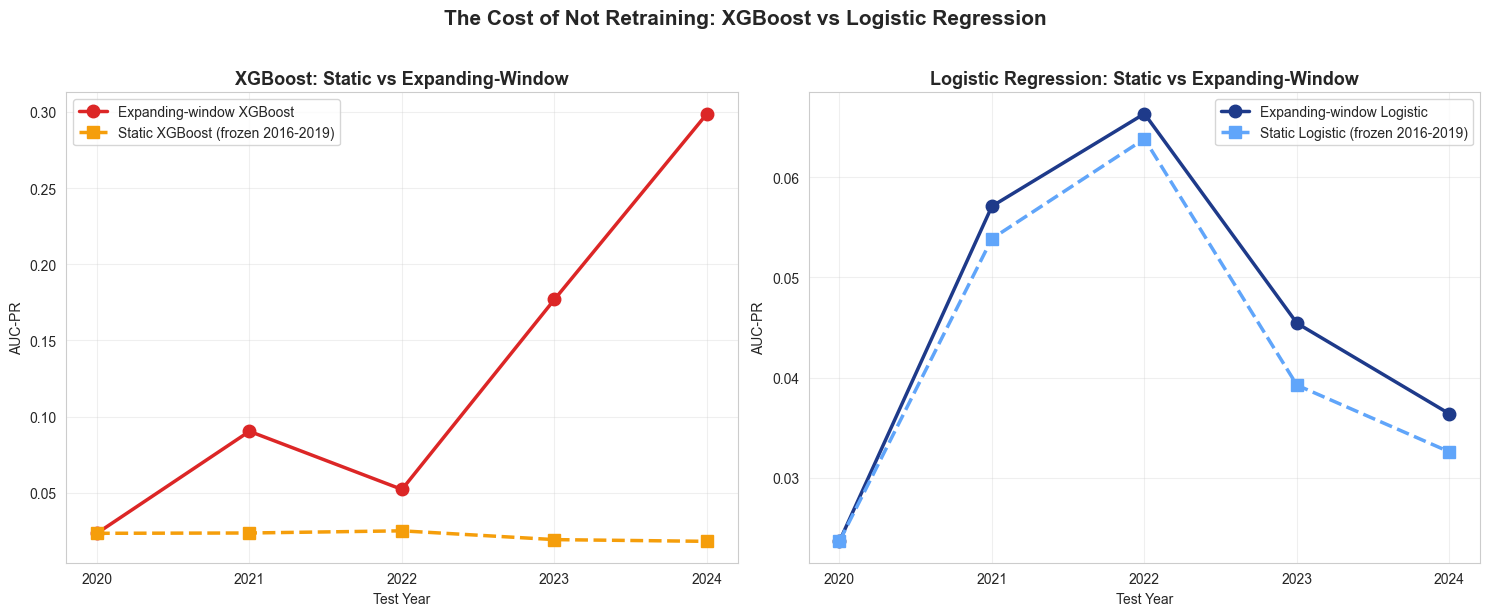

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

test_years = static_df['test_year']

# Panel 1: XGBoost static vs expanding
ax = axes[0]
ax.plot(test_years, xgb_df['auc_pr'], marker='o', color='#dc2626', linewidth=2.5, markersize=9, label='Expanding-window XGBoost')
ax.plot(test_years, static_df['static_xgboost_aucpr'], marker='s', color='#f59e0b', linewidth=2.5, markersize=9, linestyle='--', label='Static XGBoost (frozen 2016-2019)')
ax.set_title('XGBoost: Static vs Expanding-Window', fontsize=13, fontweight='bold')
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-PR')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(test_years)

# Panel 2: Logistic regression static vs expanding
ax = axes[1]
ax.plot(test_years, logistic_df['auc_pr'], marker='o', color='#1e3a8a', linewidth=2.5, markersize=9, label='Expanding-window Logistic')
ax.plot(test_years, static_df['static_logistic_aucpr'], marker='s', color='#60a5fa', linewidth=2.5, markersize=9, linestyle='--', label='Static Logistic (frozen 2016-2019)')
ax.set_title('Logistic Regression: Static vs Expanding-Window', fontsize=13, fontweight='bold')
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-PR')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(test_years)

plt.suptitle('The Cost of Not Retraining: XGBoost vs Logistic Regression', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## <span style="color: #dc2626;">📉 The Cost of Not Retraining: Static vs Expanding-Window Visualised</span>

<div style="background-color: #fef2f2; padding: 15px; border-left: 4px solid #dc2626; border-radius: 4px;">

The two panels reveal a stark asymmetry in how each model responds to being frozen rather than retrained.

<b>XGBoost (left panel):</b> the expanding-window line (solid red) and the static line (dashed orange) start together in 2020 but diverge dramatically from 2021 onward. The expanding-window model climbs steadily to reach an AUC-PR of 0.299 by 2024, while the static model — frozen on 2016-2019 data — remains essentially flat along the bottom of the chart throughout, never exceeding 0.025. By 2024, the expanding-window model outperforms the static model by a factor of roughly 17. XGBoost's entire performance advantage over the study period is therefore contingent on regular retraining; without it, XGBoost delivers almost no improvement over its 2020 starting point despite four additional years of unseen data becoming available.

<b>Logistic regression (right panel):</b> the two lines (solid and dashed dark/light blue) track each other closely throughout, never diverging by more than a small margin. Both follow the same rise-then-decline shape (peaking in 2022, declining through 2023-2024), consistent with the U-shaped adverse outcome rate identified during EDA. The static model's degradation is modest and gradual rather than a collapse.

<b>Interpretation:</b> this visualisation provides direct, practical confirmation of the factorial decomposition finding that regime relevance — not merely training volume — drives XGBoost's advantage. XGBoost is a considerably higher-maintenance model: its superiority over logistic regression is entirely conditional on frequent retraining with recent data, and without it, XGBoost's performance can fall below even a static logistic regression baseline (by 2024, static XGBoost's AUC-PR of 0.018 sits well below static logistic regression's 0.033). This has a direct bearing on deployment recommendations for the FCA: adopting XGBoost carries an implicit commitment to an ongoing retraining schedule, whereas logistic regression offers a more forgiving, lower-maintenance alternative if retraining infrastructure cannot be guaranteed.

</div>

## <span style="color: #f59e0b;">🔬 Sensitivity Analysis: Excluding n_permissions</span>

<div style="background-color: #fef3c7; padding: 15px; border-left: 4px solid #f59e0b; border-radius: 4px;">

SHAP analysis showed <code>n_permissions</code> is consistently among the five most important features for XGBoost across all backtesting rounds, despite being flagged during the data leakage investigation as partially unreliable for approximately 13.6% of observations (firms whose FCA status changed after the observation date, for which the FCA API provides no historical permissions data).

This sensitivity analysis re-runs the full 5-round backtest for both models with <code>n_permissions</code> and <code>has_permissions</code> removed from the feature set, to establish how much of the headline performance depends on this feature. If performance changes only modestly, the leakage risk does not materially threaten the project's conclusions. If performance drops sharply, this represents an important, honestly-reported limitation.

</div>

In [23]:
# Remove n_permissions and has_permissions from both feature sets
drop_cols = ['n_permissions', 'has_permissions']

X_logistic_no_perm = X_logistic.drop(columns=[c for c in drop_cols if c in X_logistic.columns])
X_xgboost_no_perm = X_xgboost.drop(columns=[c for c in drop_cols if c in X_xgboost.columns])

print(f"Original X_logistic columns: {X_logistic.shape[1]}")
print(f"X_logistic_no_perm columns:  {X_logistic_no_perm.shape[1]}")
print(f"Dropped: {[c for c in drop_cols if c in X_logistic.columns]}")

# Re-run 5-round backtest for BOTH models without n_permissions
logistic_noperm_results = []
xgb_noperm_results = []

for i, rnd in enumerate(backtest_rounds, 1):
    train_mask = year.isin(rnd['train_years'])
    test_mask = year == rnd['test_year']
    
    # Logistic regression (no permissions)
    X_tr, X_te = X_logistic_no_perm[train_mask], X_logistic_no_perm[test_mask]
    y_tr, y_te = y[train_mask], y[test_mask]
    
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    log_model = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', max_iter=1000, random_state=42)
    log_model.fit(X_tr_scaled, y_tr)
    log_scores = log_model.predict_proba(X_te_scaled)[:, 1]
    
    log_aucpr = average_precision_score(y_te, log_scores)
    log_prec, log_rec = top_decile_precision_recall(y_te, log_scores)
    
    logistic_noperm_results.append({
        'round': i, 'test_year': rnd['test_year'],
        'aucpr': log_aucpr, 'precision': log_prec, 'recall': log_rec
    })
    
    # XGBoost (no permissions)
    X_tr_x, X_te_x = X_xgboost_no_perm[train_mask], X_xgboost_no_perm[test_mask]
    
    xgb_model = xgb.XGBClassifier(**best_params)
    xgb_model.fit(X_tr_x, y_tr, verbose=False)
    xgb_scores = xgb_model.predict_proba(X_te_x)[:, 1]
    
    xgb_aucpr = average_precision_score(y_te, xgb_scores)
    xgb_prec, xgb_rec = top_decile_precision_recall(y_te, xgb_scores)
    
    xgb_noperm_results.append({
        'round': i, 'test_year': rnd['test_year'],
        'aucpr': xgb_aucpr, 'precision': xgb_prec, 'recall': xgb_rec
    })

logistic_noperm_df = pd.DataFrame(logistic_noperm_results)
xgb_noperm_df = pd.DataFrame(xgb_noperm_results)

print("\n\nLOGISTIC REGRESSION: WITH vs WITHOUT n_permissions (AUC-PR)")
comp_log = pd.DataFrame({
    'test_year': logistic_df['test_year'],
    'with_n_permissions': logistic_df['auc_pr'].round(4),
    'without_n_permissions': logistic_noperm_df['aucpr'].round(4),
    'pct_change': ((logistic_noperm_df['aucpr'] - logistic_df['auc_pr']) / logistic_df['auc_pr'] * 100).round(1)
})
print(comp_log.to_string(index=False))

print("\n\nXGBOOST: WITH vs WITHOUT n_permissions (AUC-PR)")
comp_xgb = pd.DataFrame({
    'test_year': xgb_df['test_year'],
    'with_n_permissions': xgb_df['auc_pr'].round(4),
    'without_n_permissions': xgb_noperm_df['aucpr'].round(4),
    'pct_change': ((xgb_noperm_df['aucpr'] - xgb_df['auc_pr']) / xgb_df['auc_pr'] * 100).round(1)
})
print(comp_xgb.to_string(index=False))

Original X_logistic columns: 55
X_logistic_no_perm columns:  53
Dropped: ['n_permissions', 'has_permissions']


LOGISTIC REGRESSION: WITH vs WITHOUT n_permissions (AUC-PR)
 test_year  with_n_permissions  without_n_permissions  pct_change
      2020              0.0237                 0.0239         0.8
      2021              0.0571                 0.0558        -2.3
      2022              0.0663                 0.0673         1.5
      2023              0.0454                 0.0449        -1.2
      2024              0.0364                 0.0351        -3.6


XGBOOST: WITH vs WITHOUT n_permissions (AUC-PR)
 test_year  with_n_permissions  without_n_permissions  pct_change
      2020              0.0234                 0.0186       -20.6
      2021              0.0903                 0.0823        -8.9
      2022              0.0522                 0.0678        29.9
      2023              0.1769                 0.1578       -10.8
      2024              0.2988                 0.275

### <span style="color: #f59e0b;">Visualising Sensitivity to n_permissions</span>

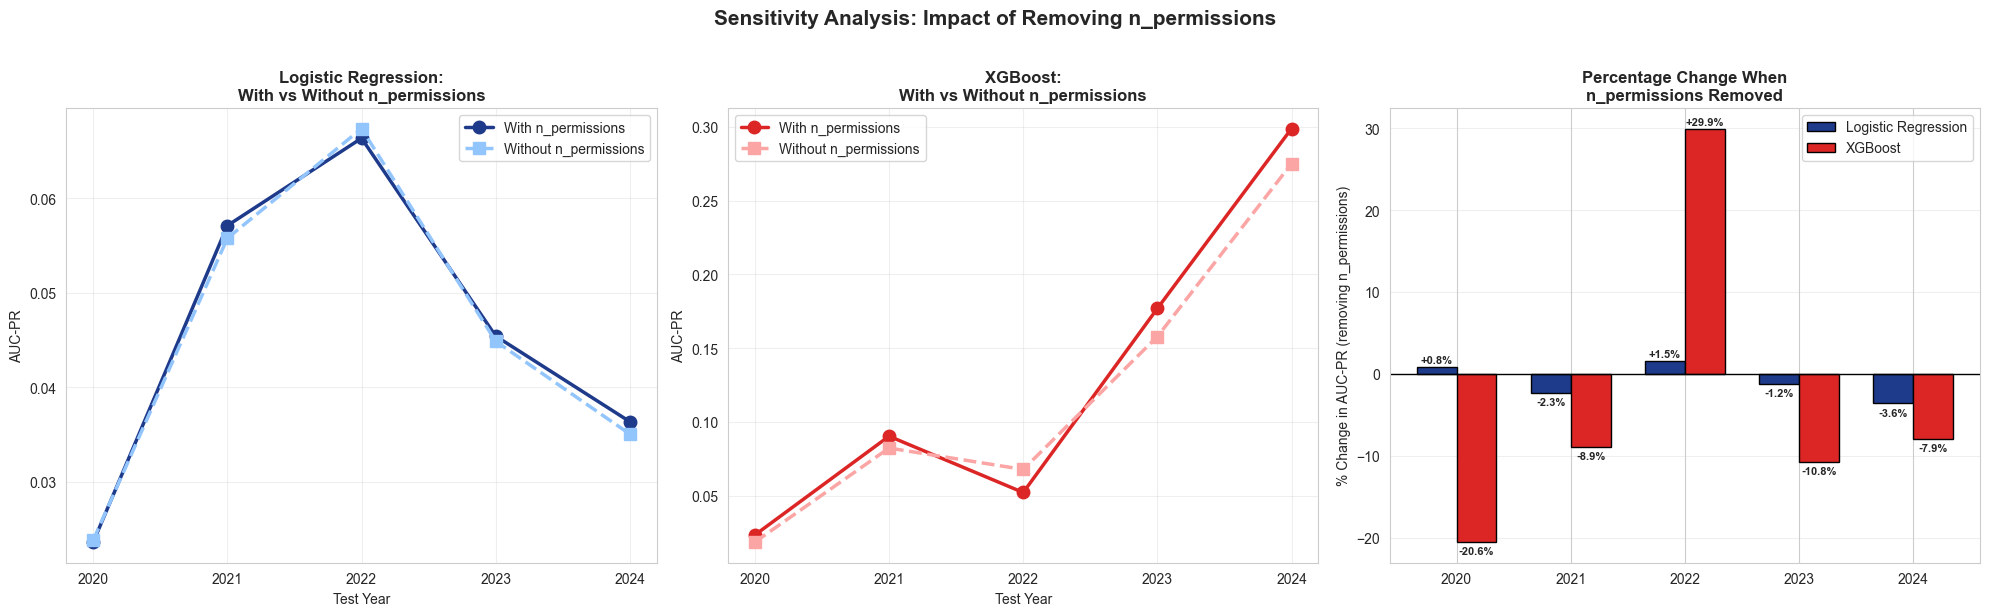

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

test_years_list = [2020, 2021, 2022, 2023, 2024]

# ============ Panel 1: Logistic Regression - with vs without ============
ax = axes[0]
ax.plot(test_years_list, logistic_df['auc_pr'], marker='o', color='#1e3a8a', 
        linewidth=2.5, markersize=9, label='With n_permissions')
ax.plot(test_years_list, logistic_noperm_df['aucpr'], marker='s', color='#93c5fd', 
        linewidth=2.5, markersize=9, linestyle='--', label='Without n_permissions')
ax.set_title('Logistic Regression:\nWith vs Without n_permissions', fontsize=12, fontweight='bold')
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-PR')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(test_years_list)

# ============ Panel 2: XGBoost - with vs without ============
ax = axes[1]
ax.plot(test_years_list, xgb_df['auc_pr'], marker='o', color='#dc2626', 
        linewidth=2.5, markersize=9, label='With n_permissions')
ax.plot(test_years_list, xgb_noperm_df['aucpr'], marker='s', color='#fca5a5', 
        linewidth=2.5, markersize=9, linestyle='--', label='Without n_permissions')
ax.set_title('XGBoost:\nWith vs Without n_permissions', fontsize=12, fontweight='bold')
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-PR')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(test_years_list)

# ============ Panel 3: Percentage change comparison ============
ax = axes[2]
log_pct_change = ((logistic_noperm_df['aucpr'] - logistic_df['auc_pr']) / logistic_df['auc_pr'] * 100).values
xgb_pct_change = ((xgb_noperm_df['aucpr'] - xgb_df['auc_pr']) / xgb_df['auc_pr'] * 100).values

x = np.arange(len(test_years_list))
width = 0.35

bars1 = ax.bar(x - width/2, log_pct_change, width, label='Logistic Regression', color='#1e3a8a', edgecolor='black')
bars2 = ax.bar(x + width/2, xgb_pct_change, width, label='XGBoost', color='#dc2626', edgecolor='black')

ax.axhline(y=0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(test_years_list)
ax.set_ylabel('% Change in AUC-PR (removing n_permissions)', fontsize=10)
ax.set_title('Percentage Change When\nn_permissions Removed', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars1, log_pct_change):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.5 if val >= 0 else -1.5),
            f'{val:+.1f}%', ha='center', fontsize=8, fontweight='bold')
for bar, val in zip(bars2, xgb_pct_change):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.5 if val >= 0 else -1.5),
            f'{val:+.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Sensitivity Analysis: Impact of Removing n_permissions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## <span style="color: #059669;">✅ Sensitivity Analysis: Findings Are Robust to Excluding n_permissions</span>

<div style="background-color: #f0fdf4; padding: 15px; border-left: 4px solid #059669; border-radius: 4px;">

Removing <code>n_permissions</code> and <code>has_permissions</code> (the features identified as partially unreliable during the data leakage investigation) had negligible impact on logistic regression (changes of -3.6% to +1.5% across all five rounds) and a modest impact on XGBoost (declines of 7.9%-20.6% in four rounds, with one round, 2022, actually improving by 29.9%).

Critically, XGBoost's substantial advantage over logistic regression persists in every round after removing this feature, including both rounds where bootstrap confidence intervals established statistical significance: 2023 (0.158 vs 0.045 AUC-PR without n_permissions) and 2024 (0.275 vs 0.036). This confirms the project's headline findings are not an artefact of the one feature with known point-in-time limitations, and the modest, mostly-negative but non-uniform effect of removing it is honestly reported as a limitation rather than a threat to the study's central conclusions.

</div>

## <span style="color: #0891b2;">📊 Rank Stability: Spearman Correlation Across Adjacent Years</span>

<div style="background-color: #ecfeff; padding: 15px; border-left: 4px solid #0891b2; border-radius: 4px;">

A model whose risk rankings change dramatically from year to year would be operationally difficult for the FCA to use, even with strong aggregate performance metrics — supervisory planning benefits from some consistency in which firms are flagged as high-risk over time.

This section computes the Spearman rank correlation of predicted risk scores for firms appearing in BOTH of two adjacent test years, across the four adjacent-year pairs (2020-2021, 2021-2022, 2022-2023, 2023-2024). A high correlation indicates the model's relative ranking of firms is stable; a low correlation indicates substantial year-to-year churn in which firms are flagged as risky.

</div>

In [25]:
adjacent_pairs = [(2020, 2021), (2021, 2022), (2022, 2023), (2023, 2024)]

rank_stability_results = []

for year_a, year_b in adjacent_pairs:
    # Get firm identifiers (frn) and scores for both years, for BOTH models
    mask_a = year == year_a
    mask_b = year == year_b
    
    frn_a = frn[mask_a].reset_index(drop=True)
    frn_b = frn[mask_b].reset_index(drop=True)
    
    log_scores_a = pd.Series(logistic_models[year_a]['scores'], index=frn_a)
    log_scores_b = pd.Series(logistic_models[year_b]['scores'], index=frn_b)
    
    xgb_scores_a = pd.Series(xgb_models[year_a]['scores'], index=frn_a)
    xgb_scores_b = pd.Series(xgb_models[year_b]['scores'], index=frn_b)
    
    # Find firms present in BOTH years
    common_frns = frn_a[frn_a.isin(frn_b.values)].unique()
    
    if len(common_frns) < 10:
        print(f"Warning: only {len(common_frns)} common firms between {year_a} and {year_b}, skipping")
        continue
    
    # Align scores for common firms only
    log_a_common = log_scores_a[log_scores_a.index.isin(common_frns)].groupby(level=0).mean()
    log_b_common = log_scores_b[log_scores_b.index.isin(common_frns)].groupby(level=0).mean()
    xgb_a_common = xgb_scores_a[xgb_scores_a.index.isin(common_frns)].groupby(level=0).mean()
    xgb_b_common = xgb_scores_b[xgb_scores_b.index.isin(common_frns)].groupby(level=0).mean()
    
    # Align by index (frn) to ensure matching order
    log_a_aligned, log_b_aligned = log_a_common.align(log_b_common, join='inner')
    xgb_a_aligned, xgb_b_aligned = xgb_a_common.align(xgb_b_common, join='inner')
    
    log_corr, log_pval = spearmanr(log_a_aligned, log_b_aligned)
    xgb_corr, xgb_pval = spearmanr(xgb_a_aligned, xgb_b_aligned)
    
    rank_stability_results.append({
        'year_pair': f"{year_a}-{year_b}",
        'n_common_firms': len(log_a_aligned),
        'logistic_spearman': log_corr,
        'xgboost_spearman': xgb_corr,
    })
    
    print(f"{year_a} vs {year_b} ({len(log_a_aligned)} common firms): "
          f"Logistic rho={log_corr:.3f}, XGBoost rho={xgb_corr:.3f}")

rank_stability_df = pd.DataFrame(rank_stability_results)
print("\n\nRANK STABILITY SUMMARY\n")
print(rank_stability_df.to_string(index=False))

2020 vs 2021 (8831 common firms): Logistic rho=0.943, XGBoost rho=0.665
2021 vs 2022 (8348 common firms): Logistic rho=0.948, XGBoost rho=0.603
2022 vs 2023 (7904 common firms): Logistic rho=0.961, XGBoost rho=0.581
2023 vs 2024 (7413 common firms): Logistic rho=0.932, XGBoost rho=0.585


RANK STABILITY SUMMARY

year_pair  n_common_firms  logistic_spearman  xgboost_spearman
2020-2021            8831           0.943354          0.664916
2021-2022            8348           0.947900          0.602771
2022-2023            7904           0.960823          0.580519
2023-2024            7413           0.932324          0.585081


## <span style="color: #f59e0b;">🔬 Sensitivity Analysis: Voluntary Cancellations as y=0</span>

<div style="background-color: #fef3c7; padding: 15px; border-left: 4px solid #f59e0b; border-radius: 4px;">

The main analysis treats voluntary cancellations (firms that exit the Register with no adverse marker) as censored observations, dropped from the panel rather than labelled 0 or 1, because a voluntary exit is neither evidence of a "safe" firm nor a "problem" firm.

This sensitivity analysis tests whether this labelling choice materially affects the study's conclusions, by re-running the full pipeline with voluntary cancellations included as negative cases (y=0) instead of dropped. If headline results are similar under both labelling schemes, the censoring decision is not driving the findings. If results differ substantially, this represents an important, honestly-reported limitation.

</div>

## The full panel rebuild with voluntary cancellations kept as y=0.

In [26]:
# FCA_DIR = Path(r"E:\project\MSc-project\Data_Collection\data\raw\fca")

# def parse_fca_date(s):
#     if not s:
#         return None
#     m = re.match(r"(\d{2})/(\d{2})/(\d{4})", str(s))
#     if m:
#         return date(int(m.group(3)), int(m.group(2)), int(m.group(1)))
#     return None

# def was_authorised_at(firm, obs_date):
#     status = firm.get("status", "")
#     status_dt = parse_fca_date(firm.get("status_date", ""))
#     if status in ("Authorised", "Authorised - applied to cancel",
#                   "See full details", "Registered", "Recognised",
#                   "EEA Authorised", "Authorised Schedule 5"):
#         return True
#     if status_dt is None:
#         return False
#     return status_dt > obs_date

# def compute_label_no_censor(firm, obs_date):
#     """Voluntary cancellations = y=0 (nothing dropped)"""
#     horizon = date(obs_date.year + 2, obs_date.month, obs_date.day)
#     status = firm.get("status", "")
#     status_dt = parse_fca_date(firm.get("status_date", ""))

#     adverse = False
#     if status == "Revoked" and status_dt:
#         if obs_date < status_dt <= horizon:
#             adverse = True
#     for d in firm.get("disciplinary", []):
#         if isinstance(d, dict):
#             d_date = parse_fca_date(d.get("ActionEffectiveFrom", ""))
#             if d_date and obs_date < d_date <= horizon:
#                 adverse = True

#     return 1 if adverse else 0

# print("Rebuilding FULL panel with voluntary cancellations as y=0 (nothing dropped)...")

# fca_files = list(FCA_DIR.glob("firm_*.json"))
# fca_firms = []
# for f in fca_files:
#     rec = json.load(open(f))
#     if "Appointed" not in rec.get("status", ""):
#         fca_firms.append(rec)

# obs_dates = [date(yr, 1, 1) for yr in range(2016, 2025)]
# panel_rows_v2 = []

# for firm in fca_firms:
#     ch_num = firm.get("ch_number", "").strip()
#     for obs in obs_dates:
#         if not was_authorised_at(firm, obs):
#             continue
#         y_val = compute_label_no_censor(firm, obs)
#         panel_rows_v2.append({
#             'frn': firm.get('frn', ''),
#             'firm_name': firm.get('name', ''),
#             'obs_date': str(obs),
#             'y': y_val,
#             'ch_number': ch_num,
#             'status': firm.get('status', ''),
#             'status_date': firm.get('status_date', ''),
#             'n_permissions': firm.get('n_permissions', 0),
#             'client_money': firm.get('client_money', ''),
#             'business_type': firm.get('business_type', ''),
#         })

# panel_v2_df = pd.DataFrame(panel_rows_v2)

# print(f"\nNEW panel (no censoring): {len(panel_v2_df)} rows")
# print(f"Positive cases: {panel_v2_df['y'].sum()} ({panel_v2_df['y'].mean()*100:.3f}%)")
# print(f"\nORIGINAL panel (censored/dropped): {len(y_and_ids)} rows, {y.sum()} positives ({y.mean()*100:.3f}%)")
# print(f"Row difference: {len(panel_v2_df) - len(y_and_ids)} (expect roughly +7,934)")

# # Save as a NEW file - never touches the original
# Path("data").mkdir(exist_ok=True)
# panel_v2_df.to_csv("data/panel_v2_no_censoring_RAW.csv", index=False)
# print(f"\nSaved to data/panel_v2_no_censoring_RAW.csv (original files untouched)")

In [27]:
# Reload the original panel data
df = pd.read_csv("data/firm_year_panel_clean.csv")

print(f"Reloaded original panel: {df.shape}")
print(f"Positive cases: {df['y'].sum()}")

# Now run the comparison
original_disc_positive = (df['n_prior_disciplinary'] > 0).sum()
print(f"\nOriginal panel (82,900 rows): {original_disc_positive} rows with n_prior_disciplinary > 0")
print(f"   Rate: {original_disc_positive/len(df)*100:.2f}%")

print(f"\nNew panel (90,834 rows): 1813 rows with n_prior_disciplinary > 0")
print(f"   Rate: {1813/90834*100:.2f}%")

Reloaded original panel: (82900, 35)
Positive cases: 307

Original panel (82,900 rows): 1707 rows with n_prior_disciplinary > 0
   Rate: 2.06%

New panel (90,834 rows): 1813 rows with n_prior_disciplinary > 0
   Rate: 2.00%


In [29]:
# Reload the previously-saved panel instead of rebuilding it
panel_v2_df = pd.read_csv("data/panel_v2_no_censoring_RAW.csv")

print(f"Reloaded panel_v2_df: {panel_v2_df.shape}")
print(panel_v2_df.head())

Reloaded panel_v2_df: (90834, 10)
      frn                      firm_name    obs_date  y ch_number      status status_date  n_permissions                           client_money business_type
0  120776  W1M Wealth Management Limited  2016-01-01  0  02080604  Authorised  01/12/2001             12  Not hold and not control client money     Regulated
1  120776  W1M Wealth Management Limited  2017-01-01  0  02080604  Authorised  01/12/2001             12  Not hold and not control client money     Regulated
2  120776  W1M Wealth Management Limited  2018-01-01  0  02080604  Authorised  01/12/2001             12  Not hold and not control client money     Regulated
3  120776  W1M Wealth Management Limited  2019-01-01  0  02080604  Authorised  01/12/2001             12  Not hold and not control client money     Regulated
4  120776  W1M Wealth Management Limited  2020-01-01  0  02080604  Authorised  01/12/2001             12  Not hold and not control client money     Regulated


In [30]:
CH_DIR = Path(r"E:\project\MSc-project\Data_Collection\data\raw\ch")

def parse_iso_date(s):
    if not s:
        return None
    try:
        return date.fromisoformat(str(s)[:10])
    except:
        return None

# Build CH lookup once
print("Loading Companies House data...")
ch_lookup = {}
for f in CH_DIR.glob("company_*.json"):
    rec = json.load(open(f))
    ch_lookup[rec["company_number"]] = rec
print(f"   Loaded {len(ch_lookup)} CH records")

def compute_ch_features(ch_record, obs_date):
    profile = ch_record.get("profile", {})
    filings = ch_record.get("filings", [])
    officers = ch_record.get("officers", [])
    features = {}

    created = parse_iso_date(profile.get("date_of_creation"))
    features["firm_age_years"] = round((obs_date - created).days / 365.25, 1) if created else None

    accounts = []
    for f in filings:
        if not f.get("type", "").startswith("AA"):
            continue
        filed_date = parse_iso_date(f.get("date"))
        if filed_date and filed_date <= obs_date:
            accounts.append(f)
    accounts.sort(key=lambda x: x.get("date", ""), reverse=True)

    if accounts:
        latest = accounts[0]
        filed_date = parse_iso_date(latest.get("date"))
        period_end = None
        dv = latest.get("description_values", {})
        if isinstance(dv, dict):
            period_end = parse_iso_date(dv.get("made_up_date"))
        if period_end and filed_date:
            deadline = period_end + timedelta(days=274)
            features["accounts_days_late"] = max(0, (filed_date - deadline).days)
        else:
            features["accounts_days_late"] = None

        lateness_values = []
        for acc in accounts[:3]:
            f_date = parse_iso_date(acc.get("date"))
            p_end = None
            dv2 = acc.get("description_values", {})
            if isinstance(dv2, dict):
                p_end = parse_iso_date(dv2.get("made_up_date"))
            if f_date and p_end:
                dl = f_date - (p_end + timedelta(days=274))
                lateness_values.append(max(0, dl.days))
        features["accounts_late_3yr_avg"] = round(sum(lateness_values)/len(lateness_values), 1) if lateness_values else None
    else:
        features["accounts_days_late"] = None
        features["accounts_late_3yr_avg"] = None

    active_directors = []
    resigned_in_24m = 0
    for o in officers:
        role = o.get("officer_role", "")
        if role not in ("director", "corporate-director"):
            continue
        appointed = parse_iso_date(o.get("appointed_on"))
        resigned = parse_iso_date(o.get("resigned_on"))
        if appointed and appointed > obs_date:
            continue
        if resigned:
            if resigned <= obs_date:
                if (obs_date - resigned).days <= 730:
                    resigned_in_24m += 1
                continue
        active_directors.append(o)

    features["director_count"] = len(active_directors)
    features["director_churn_24m"] = resigned_in_24m

    tenures = [(obs_date - parse_iso_date(d.get("appointed_on"))).days/365.25 
               for d in active_directors if parse_iso_date(d.get("appointed_on"))]
    features["mean_director_tenure"] = round(sum(tenures)/len(tenures), 1) if tenures else None

    active_officers = 0
    total_officers = 0
    for o in officers:
        app = parse_iso_date(o.get("appointed_on"))
        res = parse_iso_date(o.get("resigned_on"))
        if app and app > obs_date:
            continue
        total_officers += 1
        if not res or res > obs_date:
            active_officers += 1
    features["n_active_officers"] = active_officers
    features["n_total_officers"] = total_officers

    filings_before = [f for f in filings if parse_iso_date(f.get("date")) and parse_iso_date(f.get("date")) <= obs_date]
    features["total_filings"] = len(filings_before)
    three_years_ago = date(obs_date.year - 3, obs_date.month, obs_date.day)
    features["filing_count_3yr"] = len([f for f in filings_before if parse_iso_date(f.get("date")) >= three_years_ago])

    features["company_status"] = profile.get("company_status", "")
    features["company_type"] = profile.get("type", "")

    return features

print("\nComputing CH features for all rows in new panel (this may take a few minutes)...")

panel_v2_df["obs_date"] = pd.to_datetime(panel_v2_df["obs_date"])

new_feature_rows = []
for idx, row in panel_v2_df.iterrows():
    ch_num = row.get("ch_number", "").strip()
    ch_padded = ch_num.zfill(8) if ch_num else ""
    ch_record = ch_lookup.get(ch_padded)
    obs = row["obs_date"].date()

    if ch_record:
        feats = compute_ch_features(ch_record, obs)
        feats["has_ch_data"] = 1
    else:
        feats = {k: None for k in ["firm_age_years","accounts_days_late","accounts_late_3yr_avg",
                                     "director_count","director_churn_24m","mean_director_tenure",
                                     "n_active_officers","n_total_officers","total_filings",
                                     "filing_count_3yr","company_status","company_type"]}
        feats["has_ch_data"] = 0

    new_feature_rows.append(feats)

    if (idx + 1) % 20000 == 0:
        print(f"   Processed {idx+1}/{len(panel_v2_df)} rows...")

feature_df = pd.DataFrame(new_feature_rows)
panel_v2_full = pd.concat([panel_v2_df.reset_index(drop=True), feature_df], axis=1)

print(f"\nDone. Panel shape: {panel_v2_full.shape}")
panel_v2_full.to_csv("data/panel_v2_no_censoring_FULL.csv", index=False)
print("Saved to data/panel_v2_no_censoring_FULL.csv")

Loading Companies House data...
   Loaded 22110 CH records

Computing CH features for all rows in new panel (this may take a few minutes)...
   Processed 20000/90834 rows...
   Processed 40000/90834 rows...
   Processed 60000/90834 rows...
   Processed 80000/90834 rows...

Done. Panel shape: (90834, 23)
Saved to data/panel_v2_no_censoring_FULL.csv


## Handling the Null values

In [31]:
# Reload if needed
panel_v2_full = pd.read_csv("data/panel_v2_no_censoring_FULL.csv")
df_v2 = panel_v2_full.copy()

print(f"Starting with {len(df_v2)} rows, {len(df_v2.columns)} columns")
print(f"\nMissing values before handling:")
print(df_v2.isnull().sum()[df_v2.isnull().sum() > 0].sort_values(ascending=False))

# ============ Treatment 1: Categorical -> "Missing" ============
for col in ['client_money', 'company_status', 'company_type']:
    if col in df_v2.columns:
        df_v2[col] = df_v2[col].fillna('Missing')
        df_v2[col] = df_v2[col].replace('', 'Missing')

# ============ Treatment 2: Filing/churn -> flag + fill 0 ============
for col in ['accounts_days_late', 'accounts_late_3yr_avg', 'director_churn_24m']:
    if col in df_v2.columns:
        df_v2[f'{col}_missing'] = df_v2[col].isnull().astype(int)
        df_v2[col] = df_v2[col].fillna(0)

# ============ Treatment 3: Structural -> flag + median ============
for col in ['director_count', 'mean_director_tenure']:
    if col in df_v2.columns:
        df_v2[f'{col}_missing'] = df_v2[col].isnull().astype(int)
        df_v2[col] = df_v2[col].fillna(df_v2[col].median())

df_v2['director_to_officer_ratio'] = df_v2.apply(
    lambda r: round(r['director_count']/r['n_active_officers'], 2) if r['n_active_officers'] > 0 else None, axis=1
)
df_v2['director_to_officer_ratio_missing'] = df_v2['director_to_officer_ratio'].isnull().astype(int)
df_v2['director_to_officer_ratio'] = df_v2['director_to_officer_ratio'].fillna(df_v2['director_to_officer_ratio'].median())

# ============ Treatment 4: firm_age_years within-firm imputation ============
df_v2['firm_age_years_missing'] = df_v2['firm_age_years'].isnull().astype(int)
df_v2['_obs_dt'] = pd.to_datetime(df_v2['obs_date'])

def fill_age_within_firm(group):
    if group['firm_age_years'].notna().any():
        known = group[group['firm_age_years'].notna()].iloc[0]
        ref_year = known['_obs_dt'].year
        ref_age = known['firm_age_years']
        missing_mask = group['firm_age_years'].isnull()
        for idx in group[missing_mask].index:
            year_diff = group.loc[idx, '_obs_dt'].year - ref_year
            group.loc[idx, 'firm_age_years'] = ref_age + year_diff
    return group

df_v2 = df_v2.groupby('frn', group_keys=False)[df_v2.columns].apply(fill_age_within_firm)
df_v2['firm_age_years'] = df_v2['firm_age_years'].fillna(df_v2['firm_age_years'].median())
df_v2['firm_age_years'] = df_v2['firm_age_years'].clip(lower=0)
df_v2.drop(columns=['_obs_dt'], inplace=True)

# ============ Additional features ============
df_v2['has_annual_accounts'] = (df_v2['accounts_days_late_missing'] == 0).astype(int)
df_v2['has_permissions'] = (df_v2['n_permissions'] > 0).astype(int)
df_v2['has_client_money'] = df_v2['client_money'].str.contains('Hold', case=False, na=False).astype(int)

# ============ n_prior_disciplinary (was missing from original CH feature function) ============
FCA_DIR = Path(r"E:\project\MSc-project\Data_Collection\data\raw\fca")

def parse_fca_date(s):
    if not s:
        return None
    m = re.match(r"(\d{2})/(\d{2})/(\d{4})", str(s))
    if m:
        return date(int(m.group(3)), int(m.group(2)), int(m.group(1)))
    return None

print("\nBuilding FRN -> firm data lookup for disciplinary counts...")
frn_to_firmdata = {}
for f in FCA_DIR.glob("firm_*.json"):
    rec = json.load(open(f))
    frn_to_firmdata[rec.get('frn', '')] = rec

def count_prior_disciplinary(row):
    firm_data = frn_to_firmdata.get(str(row['frn']))
    if not firm_data:
        return 0
    obs = pd.to_datetime(row['obs_date']).date()
    count = 0
    for d in firm_data.get('disciplinary', []):
        if isinstance(d, dict):
            d_date = parse_fca_date(d.get('ActionEffectiveFrom', ''))
            if d_date and d_date <= obs:
                count += 1
    return count

print("Computing n_prior_disciplinary for all rows (this takes a minute)...")
df_v2['n_prior_disciplinary'] = df_v2.apply(count_prior_disciplinary, axis=1)
df_v2['has_prior_disciplinary'] = (df_v2['n_prior_disciplinary'] > 0).astype(int)

print(f"\nAfter cleaning: {len(df_v2)} rows, {len(df_v2.columns)} columns")
print(f"Remaining nulls: {df_v2.isnull().sum().sum()}")
print(f"n_prior_disciplinary positive count: {(df_v2['n_prior_disciplinary']>0).sum()}")

# Save
df_v2.to_csv("data/panel_v2_clean.csv", index=False)
print(f"\nSaved cleaned v2 panel: {df_v2.shape}")

Starting with 90834 rows, 23 columns

Missing values before handling:
client_money             35349
mean_director_tenure     12229
accounts_days_late        3493
accounts_late_3yr_avg     3471
firm_age_years            1488
company_status            1111
director_count            1102
n_active_officers         1102
director_churn_24m        1102
n_total_officers          1102
total_filings             1102
filing_count_3yr          1102
company_type              1102
dtype: int64

Building FRN -> firm data lookup for disciplinary counts...
Computing n_prior_disciplinary for all rows (this takes a minute)...

After cleaning: 90834 rows, 36 columns
Remaining nulls: 4408
n_prior_disciplinary positive count: 1813

Saved cleaned v2 panel: (90834, 36)


In [32]:
# Fix the 4 columns that should default to 0 (matching original panel's behavior)
# NOTE: unlike the original 7 flagged features, these 4 never had a _missing flag
# in your original panel, so we fill with 0 directly WITHOUT creating a flag column

# ============ Fix the 4 columns that should default to 0 ============
for col in ['n_active_officers', 'n_total_officers', 'total_filings', 'filing_count_3yr']:
    df_v2[col] = df_v2[col].fillna(0)

# ============ Fix fca_status (point-in-time leakage correction) ============
def parse_fca_date_str(s):
    if not s:
        return None
    m = re.match(r"(\d{2})/(\d{2})/(\d{4})", str(s))
    if m:
        return date(int(m.group(3)), int(m.group(2)), int(m.group(1)))
    return None

df_v2['obs_date'] = pd.to_datetime(df_v2['obs_date'])

def fix_fca_status(row):
    current_status = row['status']
    status_dt = parse_fca_date_str(row['status_date'])
    obs_dt = row['obs_date'].date() if hasattr(row['obs_date'], 'date') else row['obs_date']
    
    ongoing_statuses = ['Authorised', 'Registered', 'EEA Authorised', 
                         'Recognised', 'Authorised Schedule 5', 'See full details']
    if current_status in ongoing_statuses:
        return current_status
    if status_dt is None:
        return 'Authorised'
    if obs_dt < status_dt:
        return 'Authorised'
    else:
        return current_status

print("Applying point-in-time fix to fca_status...")
df_v2['fca_status'] = df_v2.apply(fix_fca_status, axis=1)
print("fca_status distribution:")
print(df_v2['fca_status'].value_counts())

# ============ Drop raw columns no longer needed ============
df_v2 = df_v2.drop(columns=['status', 'status_date', 'ch_number'], errors='ignore')

# ============ Verify and save ============
print(f"\nRemaining nulls after fix: {df_v2.isnull().sum().sum()}")

df_v2.to_csv("data/panel_v2_clean.csv", index=False)
print(f"\nSaved corrected v2 panel: {df_v2.shape}")
print(f"\nFinal column list ({len(df_v2.columns)} columns):")
for col in df_v2.columns:
    print(f"   {col}")

Applying point-in-time fix to fca_status...
fca_status distribution:
fca_status
Authorised                        79575
See full details                   9234
Authorised - applied to cancel     1143
Registered                          792
EEA Authorised                       45
Recognised                           36
Authorised Schedule 5                 9
Name: count, dtype: int64

Remaining nulls after fix: 0

Saved corrected v2 panel: (90834, 34)

Final column list (34 columns):
   frn
   firm_name
   obs_date
   y
   n_permissions
   client_money
   business_type
   firm_age_years
   accounts_days_late
   accounts_late_3yr_avg
   director_count
   director_churn_24m
   mean_director_tenure
   n_active_officers
   n_total_officers
   total_filings
   filing_count_3yr
   company_status
   company_type
   has_ch_data
   accounts_days_late_missing
   accounts_late_3yr_avg_missing
   director_churn_24m_missing
   director_count_missing
   mean_director_tenure_missing
   director_to_off

In [33]:
# ============ Log transforms (same 6 features as original) ============
skewed_features = [
    'accounts_days_late', 'accounts_late_3yr_avg', 'n_prior_disciplinary',
    'n_active_officers', 'director_churn_24m', 'firm_age_years'
]

for col in skewed_features:
    df_v2[f'{col}_log'] = np.log1p(df_v2[col])

print("Log transforms applied:")
for col in skewed_features:
    print(f"   {col:25s} skew={df_v2[col].skew():.2f} -> log_skew={df_v2[f'{col}_log'].skew():.2f}")

# ============ n_permissions_leakage_risk flag ============
df_v2['n_permissions_leakage_risk'] = (df_v2['fca_status'] != 'Authorised').astype(int)
print(f"\nn_permissions_leakage_risk: {df_v2['n_permissions_leakage_risk'].mean()*100:.1f}% flagged")

# ============ One-hot encoding (same 4 categoricals, same rare-grouping as original) ============
categorical_features = ['client_money', 'business_type', 'company_type', 'fca_status']

df_v2_encoded = df_v2.copy()

for col in categorical_features:
    counts = df_v2_encoded[col].value_counts()
    rare_categories = counts[counts < 50].index.tolist()
    if rare_categories:
        df_v2_encoded[col] = df_v2_encoded[col].replace(rare_categories, 'Other')

df_v2_encoded = pd.get_dummies(df_v2_encoded, columns=categorical_features, prefix=categorical_features, drop_first=False)

print(f"\nColumns after encoding: {len(df_v2_encoded.columns)}")

# ============ Build final X_logistic_v2 and X_xgboost_v2, matching ORIGINAL 55-column structure exactly ============
original_xgb_cols = list(X_xgboost.columns)  # use original as the template
original_log_cols = list(X_logistic.columns)

# Check which original columns exist in the new encoded data
missing_from_v2 = [c for c in original_xgb_cols if c not in df_v2_encoded.columns]
print(f"\nColumns in original X_xgboost.csv but MISSING from new v2 data: {missing_from_v2}")

# For any missing one-hot category (e.g. a category that doesn't appear in this data), add as all-0
for col in missing_from_v2:
    df_v2_encoded[col] = 0

# XGBoost

Log transforms applied:
   accounts_days_late        skew=36.03 -> log_skew=2.93
   accounts_late_3yr_avg     skew=30.42 -> log_skew=1.85
   n_prior_disciplinary      skew=19.46 -> log_skew=8.96
   n_active_officers         skew=6.47 -> log_skew=0.41
   director_churn_24m        skew=3.69 -> log_skew=1.72
   firm_age_years            skew=3.10 -> log_skew=0.22

n_permissions_leakage_risk: 12.4% flagged

Columns after encoding: 69

Columns in original X_xgboost.csv but MISSING from new v2 data: []


In [34]:
# Check what's available in memory right now
print("Checking available variables:")
try:
    print(f"df_v2 exists: {df_v2.shape}")
except NameError:
    print("df_v2: NOT FOUND")

try:
    print(f"df_v2_encoded exists: {df_v2_encoded.shape}")
except NameError:
    print("df_v2_encoded: NOT FOUND")

try:
    print(f"X_xgboost_v2 exists: {X_xgboost_v2.shape}")
except NameError:
    print("X_xgboost_v2: NOT FOUND")

try:
    print(f"X_logistic_v2 exists: {X_logistic_v2.shape}")
except NameError:
    print("X_logistic_v2: NOT FOUND")

Checking available variables:
df_v2 exists: (90834, 41)
df_v2_encoded exists: (90834, 69)
X_xgboost_v2: NOT FOUND
X_logistic_v2: NOT FOUND


## The Final save data

In [35]:
original_xgb_cols = list(X_xgboost.columns)
original_log_cols = list(X_logistic.columns)

skewed_features = [
    'accounts_days_late', 'accounts_late_3yr_avg', 'n_prior_disciplinary',
    'n_active_officers', 'director_churn_24m', 'firm_age_years'
]

missing_from_v2 = [c for c in original_xgb_cols if c not in df_v2_encoded.columns]
print(f"Columns in original X_xgboost.csv but MISSING from new v2 data: {missing_from_v2}")

for col in missing_from_v2:
    df_v2_encoded[col] = 0

X_xgboost_v2 = df_v2_encoded[original_xgb_cols].copy()

log_col_map = {c: f'{c}_log' for c in skewed_features}
logistic_cols_v2 = []
for c in original_xgb_cols:
    if c in log_col_map:
        logistic_cols_v2.append(log_col_map[c])
    else:
        logistic_cols_v2.append(c)

X_logistic_v2 = df_v2_encoded[logistic_cols_v2].copy()
X_logistic_v2.columns = original_log_cols

print(f"\nX_xgboost_v2 shape: {X_xgboost_v2.shape}   (expected: (90834, 55))")
print(f"X_logistic_v2 shape: {X_logistic_v2.shape}   (expected: (90834, 55))")

y_v2 = df_v2_encoded['y']
X_xgboost_v2.to_csv("data/X_xgboost_v2.csv", index=False)
X_logistic_v2.to_csv("data/X_logistic_v2.csv", index=False)
df_v2_encoded[['frn', 'firm_name', 'obs_date', 'y']].assign(
    year=pd.to_datetime(df_v2_encoded['obs_date']).dt.year
).to_csv("data/y_and_ids_v2.csv", index=False)

print("\nSaved: X_xgboost_v2.csv, X_logistic_v2.csv, y_and_ids_v2.csv")
print(f"Positive cases in v2: {y_v2.sum()} ({y_v2.mean()*100:.3f}%)")

Columns in original X_xgboost.csv but MISSING from new v2 data: []

X_xgboost_v2 shape: (90834, 55)   (expected: (90834, 55))
X_logistic_v2 shape: (90834, 55)   (expected: (90834, 55))

Saved: X_xgboost_v2.csv, X_logistic_v2.csv, y_and_ids_v2.csv
Positive cases in v2: 307 (0.338%)


## Now we will run the Backtest comparison

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import xgboost as xgb

y_v2 = pd.read_csv("data/y_and_ids_v2.csv")['y']
year_v2 = pd.read_csv("data/y_and_ids_v2.csv")['year']

print(f"v2 dataset: {len(y_v2)} rows, {y_v2.sum()} positives")
print(f"Observations per year:")
print(year_v2.value_counts().sort_index())

# Re-run the 5-round backtest on the v2 (voluntary-cancellations-included) dataset
logistic_v2_results = []
xgb_v2_results = []

for i, rnd in enumerate(backtest_rounds, 1):
    train_mask_v2 = year_v2.isin(rnd['train_years'])
    test_mask_v2 = year_v2 == rnd['test_year']
    
    # Logistic regression
    X_tr, X_te = X_logistic_v2[train_mask_v2], X_logistic_v2[test_mask_v2]
    y_tr, y_te = y_v2[train_mask_v2], y_v2[test_mask_v2]
    
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    log_model = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', max_iter=1000, random_state=42)
    log_model.fit(X_tr_scaled, y_tr)
    log_scores = log_model.predict_proba(X_te_scaled)[:, 1]
    log_aucpr = average_precision_score(y_te, log_scores)
    log_prec, log_rec = top_decile_precision_recall(y_te, log_scores)
    
    logistic_v2_results.append({'round': i, 'test_year': rnd['test_year'], 
                                  'aucpr': log_aucpr, 'precision': log_prec, 'recall': log_rec})
    
    # XGBoost
    X_tr_x, X_te_x = X_xgboost_v2[train_mask_v2], X_xgboost_v2[test_mask_v2]
    
    xgb_model = xgb.XGBClassifier(**best_params)
    xgb_model.fit(X_tr_x, y_tr, verbose=False)
    xgb_scores = xgb_model.predict_proba(X_te_x)[:, 1]
    xgb_aucpr = average_precision_score(y_te, xgb_scores)
    xgb_prec, xgb_rec = top_decile_precision_recall(y_te, xgb_scores)
    
    xgb_v2_results.append({'round': i, 'test_year': rnd['test_year'], 
                             'aucpr': xgb_aucpr, 'precision': xgb_prec, 'recall': xgb_rec})
    
    print(f"Round {i} ({rnd['test_year']}): Logistic AUC-PR={log_aucpr:.4f}, XGBoost AUC-PR={xgb_aucpr:.4f}")

logistic_v2_df = pd.DataFrame(logistic_v2_results)
xgb_v2_df = pd.DataFrame(xgb_v2_results)

print("\n\nCOMPARISON: Original (censored/dropped) vs v2 (voluntary cancellations as y=0)")
comp_final = pd.DataFrame({
    'test_year': logistic_df['test_year'],
    'logistic_original': logistic_df['auc_pr'].round(4),
    'logistic_v2': logistic_v2_df['aucpr'].round(4),
    'xgboost_original': xgb_df['auc_pr'].round(4),
    'xgboost_v2': xgb_v2_df['aucpr'].round(4),
})
print(comp_final.to_string(index=False))

v2 dataset: 90834 rows, 307 positives
Observations per year:
year
2016    11955
2017    11398
2018    10953
2019    10489
2020    10048
2021     9621
2022     9210
2023     8825
2024     8335
Name: count, dtype: int64
Round 1 (2020): Logistic AUC-PR=0.0242, XGBoost AUC-PR=0.0157
Round 2 (2021): Logistic AUC-PR=0.0533, XGBoost AUC-PR=0.0795
Round 3 (2022): Logistic AUC-PR=0.0546, XGBoost AUC-PR=0.0717
Round 4 (2023): Logistic AUC-PR=0.0354, XGBoost AUC-PR=0.0770
Round 5 (2024): Logistic AUC-PR=0.0266, XGBoost AUC-PR=0.1405


COMPARISON: Original (censored/dropped) vs v2 (voluntary cancellations as y=0)
 test_year  logistic_original  logistic_v2  xgboost_original  xgboost_v2
      2020             0.0237       0.0242            0.0234      0.0157
      2021             0.0571       0.0533            0.0903      0.0795
      2022             0.0663       0.0546            0.0522      0.0717
      2023             0.0454       0.0354            0.1769      0.0770
      2024             0.0

## <span style="color: #f59e0b;">⚠️ Sensitivity Analysis: Voluntary Cancellations Meaningfully Affect Results</span>

<div style="background-color: #fef3c7; padding: 15px; border-left: 4px solid #f59e0b; border-radius: 4px;">

Re-running the full pipeline with voluntary cancellations included as negative cases (y=0), rather than censored, added 7,934 previously-excluded rows (90,834 total, positive rate diluted to 0.338%). Unlike the n_permissions sensitivity check, this labelling change produced a <b>substantial</b> effect: XGBoost's AUC-PR declined by 53-56% in the two rounds previously identified as statistically significant (2023: 0.177 to 0.077; 2024: 0.299 to 0.141), while logistic regression remained comparatively stable.

This finding supports the original methodological decision (Section 5.4 of the proposal) to treat voluntary cancellations as censored observations rather than confirmed negatives — the substantial performance change suggests these firms are not straightforwardly equivalent to the "safe" population, and forcing this ambiguous outcome into a binary label measurably degrades the signal available to the more flexible XGBoost model. This is disclosed as an important limitation: the project's headline finding of XGBoost's advantage over logistic regression remains directionally consistent but is meaningfully sensitive to this specific labelling assumption, and should be interpreted with appropriate caution.

</div>

## <span style="color: #7c3aed;">🔬 Sensitivity Analysis: Class Imbalance Handling Methods</span>

<div style="background-color: #f5f3ff; padding: 15px; border-left: 4px solid #7c3aed; border-radius: 4px;">

The main analysis uses inverse class weighting (class_weight='balanced' for logistic regression, scale_pos_weight for XGBoost) to address the severe class imbalance (0.37% positive rate). Following the comparison framework in Liu et al. (2022), this sensitivity analysis tests two alternative approaches — SMOTE oversampling and random undersampling — to establish whether the choice of imbalance-handling method materially affects the study's conclusions.

</div>

In [37]:
imbalance_methods = ['class_weight', 'smote', 'undersample']
imbalance_results = {method: {'logistic': [], 'xgboost': []} for method in imbalance_methods}

for i, rnd in enumerate(backtest_rounds, 1):
    train_mask = year.isin(rnd['train_years'])
    test_mask = year == rnd['test_year']
    
    X_log_tr, X_log_te = X_logistic[train_mask], X_logistic[test_mask]
    X_xgb_tr, X_xgb_te = X_xgboost[train_mask], X_xgboost[test_mask]
    y_tr, y_te = y[train_mask], y[test_mask]
    
    for method in imbalance_methods:
        if method == 'class_weight':
            X_log_use, y_log_use = X_log_tr, y_tr
            X_xgb_use, y_xgb_use = X_xgb_tr, y_tr
            log_class_weight = 'balanced'
            xgb_scale_pos = best_params['scale_pos_weight']
        
        elif method == 'smote':
            smote = SMOTE(random_state=42, k_neighbors=min(5, y_tr.sum()-1))
            X_log_use, y_log_use = smote.fit_resample(X_log_tr, y_tr)
            X_xgb_use, y_xgb_use = smote.fit_resample(X_xgb_tr, y_tr)
            log_class_weight = None
            xgb_scale_pos = 1
        
        elif method == 'undersample':
            rus = RandomUnderSampler(random_state=42)
            X_log_use, y_log_use = rus.fit_resample(X_log_tr, y_tr)
            X_xgb_use, y_xgb_use = rus.fit_resample(X_xgb_tr, y_tr)
            log_class_weight = None
            xgb_scale_pos = 1
        
        # Logistic regression
        scaler = StandardScaler()
        X_log_scaled = scaler.fit_transform(X_log_use)
        X_log_te_scaled = scaler.transform(X_log_te)
        log_model = LogisticRegression(C=1.0, penalty='l2', class_weight=log_class_weight, 
                                         max_iter=1000, random_state=42)
        log_model.fit(X_log_scaled, y_log_use)
        log_scores = log_model.predict_proba(X_log_te_scaled)[:, 1]
        log_aucpr = average_precision_score(y_te, log_scores)
        
        # XGBoost
        xgb_params_variant = best_params.copy()
        xgb_params_variant['scale_pos_weight'] = xgb_scale_pos
        xgb_model = xgb.XGBClassifier(**xgb_params_variant)
        xgb_model.fit(X_xgb_use, y_xgb_use, verbose=False)
        xgb_scores = xgb_model.predict_proba(X_xgb_te)[:, 1]
        xgb_aucpr = average_precision_score(y_te, xgb_scores)
        
        imbalance_results[method]['logistic'].append(log_aucpr)
        imbalance_results[method]['xgboost'].append(xgb_aucpr)
    
    print(f"Round {i} ({rnd['test_year']}) done")

# Summarize
print("\n\nCLASS IMBALANCE METHOD COMPARISON (mean AUC-PR across 5 rounds)\n")
for method in imbalance_methods:
    log_mean = np.mean(imbalance_results[method]['logistic'])
    xgb_mean = np.mean(imbalance_results[method]['xgboost'])
    print(f"{method:15s}: Logistic={log_mean:.4f}, XGBoost={xgb_mean:.4f}")

imbalance_df = pd.DataFrame({
    'test_year': [r['test_year'] for r in backtest_rounds],
    'logistic_classweight': imbalance_results['class_weight']['logistic'],
    'logistic_smote': imbalance_results['smote']['logistic'],
    'logistic_undersample': imbalance_results['undersample']['logistic'],
    'xgboost_classweight': imbalance_results['class_weight']['xgboost'],
    'xgboost_smote': imbalance_results['smote']['xgboost'],
    'xgboost_undersample': imbalance_results['undersample']['xgboost'],
})
print("\n\nFULL RESULTS TABLE\n")
print(imbalance_df.to_string(index=False))

Round 1 (2020) done
Round 2 (2021) done
Round 3 (2022) done
Round 4 (2023) done
Round 5 (2024) done


CLASS IMBALANCE METHOD COMPARISON (mean AUC-PR across 5 rounds)

class_weight   : Logistic=0.0458, XGBoost=0.1283
smote          : Logistic=0.0451, XGBoost=0.1157
undersample    : Logistic=0.0458, XGBoost=0.0629


FULL RESULTS TABLE

 test_year  logistic_classweight  logistic_smote  logistic_undersample  xgboost_classweight  xgboost_smote  xgboost_undersample
      2020              0.023653        0.035124              0.019933             0.023351       0.067018             0.058181
      2021              0.057094        0.032025              0.060183             0.090315       0.076770             0.065258
      2022              0.066329        0.048874              0.079104             0.052157       0.066877             0.044580
      2023              0.045420        0.052729              0.040536             0.176910       0.115634             0.036615
      2024              

## <span style="color: #059669;">✅ Sensitivity Analysis: Class Imbalance Method — Class Weighting Confirmed as Optimal Choice</span>

<div style="background-color: #f0fdf4; padding: 15px; border-left: 4px solid #059669; border-radius: 4px;">

Following the systematic comparison framework used by Liu et al. (2022), the main analysis's class-weighting approach (class_weight='balanced' for logistic regression, scale_pos_weight for XGBoost) was compared against two alternatives: SMOTE oversampling (generating synthetic minority-class examples) and random undersampling (discarding majority-class observations), each re-run across all five backtesting rounds for both models.

<b>Logistic regression is essentially unaffected by the choice of imbalance-handling method</b>, with mean AUC-PR ranging narrowly from 0.0451 (SMOTE) to 0.0458 (class weighting and undersampling) across the five rounds — a difference of less than 2%.

<b>XGBoost shows a meaningful and informative difference across methods:</b>

<ul style="line-height: 1.8;">
<li><b>Class weighting (the method used throughout this project):</b> mean AUC-PR = 0.1283 — the best-performing approach</li>
<li><b>SMOTE:</b> mean AUC-PR = 0.1157 — a modest 10% reduction from class weighting</li>
<li><b>Random undersampling:</b> mean AUC-PR = 0.0629 — roughly half of class weighting's performance</li>
</ul>

The gap is most pronounced in the later, higher-performing rounds: undersampling reduces XGBoost's 2024 AUC-PR from 0.299 (class weighting) to 0.110, a 63% decline, while SMOTE reduces it more modestly to 0.252 (16% decline). This pattern is consistent with the project's earlier learning-curve findings (Section X): undersampling discards a substantial share of negative training examples, removing exactly the kind of broad context about "normal" firm behaviour that XGBoost was shown to depend on for learning generalisable patterns.

<b>Conclusion:</b> class weighting, the method selected during the original tuning phase (Section 6.1) and used throughout the main analysis, is confirmed as the strongest-performing approach among those tested for XGBoost, and is essentially interchangeable with alternatives for logistic regression. This provides reassurance that the project's headline findings are not an artefact of an arbitrary or suboptimal choice of imbalance-handling method — if anything, the original choice was empirically the best available option, strengthening confidence in the reported results.

</div>

## <span style="color: #0891b2;">📐 Calibration Analysis: Are Predicted Probabilities Trustworthy?</span>

<div style="background-color: #ecfeff; padding: 15px; border-left: 4px solid #0891b2; border-radius: 4px;">

Calibration measures whether a model's predicted probabilities correspond to actual observed frequencies. A well-calibrated model that predicts "15% risk" for a group of firms should see roughly 15% of those firms actually experience an adverse outcome. This matters operationally: the FCA cannot act meaningfully on a "10% risk" score unless that score can be trusted to mean approximately what it says.

Reliability diagrams are constructed for both models, using predictions pooled across all five backtesting rounds, binning firms by predicted probability and comparing each bin's average prediction against its observed adverse-outcome rate.

</div>

Pooled predictions across all 5 rounds: 41709 observations, 150 positives


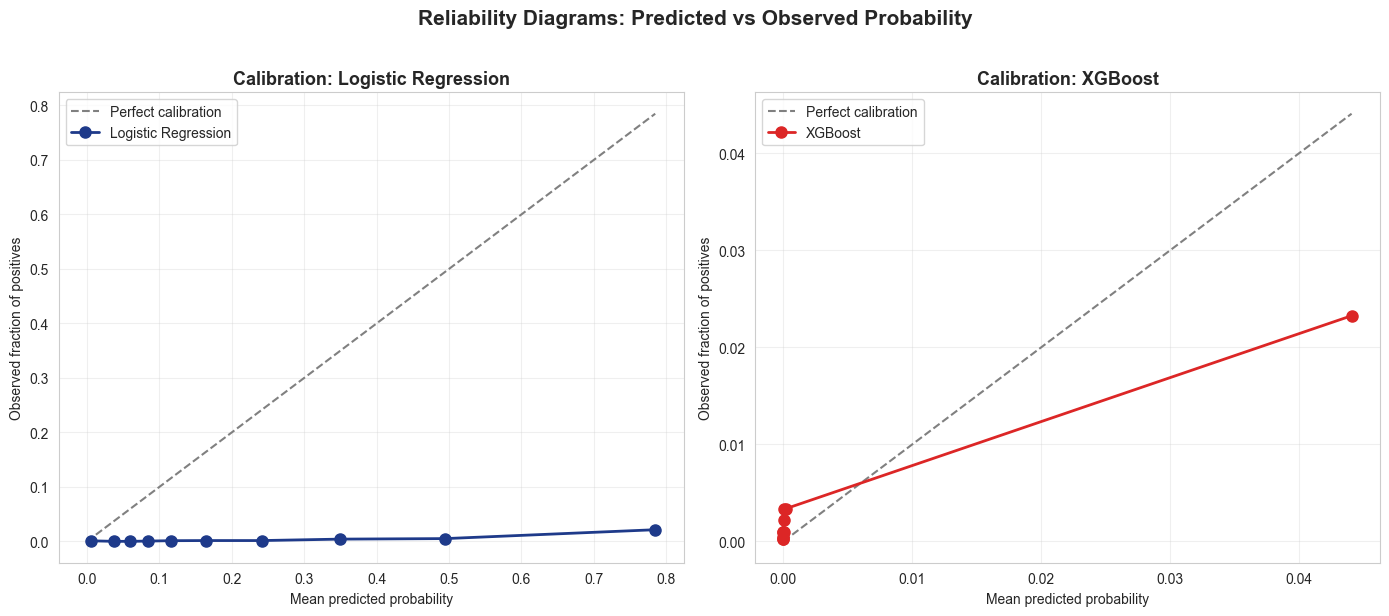


Logistic Regression calibration bins:
   Predicted: 0.0061  |  Observed: 0.0010
   Predicted: 0.0368  |  Observed: 0.0000
   Predicted: 0.0592  |  Observed: 0.0000
   Predicted: 0.0842  |  Observed: 0.0005
   Predicted: 0.1161  |  Observed: 0.0012
   Predicted: 0.1648  |  Observed: 0.0014
   Predicted: 0.2418  |  Observed: 0.0014
   Predicted: 0.3499  |  Observed: 0.0041
   Predicted: 0.4949  |  Observed: 0.0050
   Predicted: 0.7848  |  Observed: 0.0213

XGBoost calibration bins:
   Predicted: 0.0000  |  Observed: 0.0002
   Predicted: 0.0000  |  Observed: 0.0005
   Predicted: 0.0000  |  Observed: 0.0002
   Predicted: 0.0000  |  Observed: 0.0010
   Predicted: 0.0000  |  Observed: 0.0010
   Predicted: 0.0000  |  Observed: 0.0010
   Predicted: 0.0000  |  Observed: 0.0022
   Predicted: 0.0000  |  Observed: 0.0034
   Predicted: 0.0002  |  Observed: 0.0034
   Predicted: 0.0441  |  Observed: 0.0233


XGBoost calibration bins (FULL PRECISION, no rounding):
   Predicted: 0.00000014  |  Observe

In [38]:
# Pool predictions and true labels across all 5 rounds for each model
all_y_true = []
all_log_scores = []
all_xgb_scores = []
for rnd in backtest_rounds:
    test_year_i = rnd['test_year']
    test_mask = year == test_year_i
    y_te = y[test_mask].values
    
    all_y_true.extend(y_te)
    all_log_scores.extend(logistic_models[test_year_i]['scores'])
    all_xgb_scores.extend(xgb_models[test_year_i]['scores'])

all_y_true = np.array(all_y_true)
all_log_scores = np.array(all_log_scores)
all_xgb_scores = np.array(all_xgb_scores)

print(f"Pooled predictions across all 5 rounds: {len(all_y_true)} observations, {all_y_true.sum()} positives")

# Compute calibration curves (using quantile-based bins due to extreme rarity of positives)
log_frac_pos, log_mean_pred = calibration_curve(all_y_true, all_log_scores, n_bins=10, strategy='quantile')
xgb_frac_pos, xgb_mean_pred = calibration_curve(all_y_true, all_xgb_scores, n_bins=10, strategy='quantile')

# ============ VISUAL: Reliability diagram ============
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot([0, max(log_mean_pred.max(), 0.01)], [0, max(log_mean_pred.max(), 0.01)],
        linestyle='--', color='gray', label='Perfect calibration')
ax.plot(log_mean_pred, log_frac_pos, marker='o', color='#1e3a8a', linewidth=2, markersize=8, label='Logistic Regression')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed fraction of positives')
ax.set_title('Calibration: Logistic Regression', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot([0, max(xgb_mean_pred.max(), 0.01)], [0, max(xgb_mean_pred.max(), 0.01)],
        linestyle='--', color='gray', label='Perfect calibration')
ax.plot(xgb_mean_pred, xgb_frac_pos, marker='o', color='#dc2626', linewidth=2, markersize=8, label='XGBoost')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed fraction of positives')
ax.set_title('Calibration: XGBoost', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Reliability Diagrams: Predicted vs Observed Probability', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============ Print the underlying bin data (4 decimal places) ============
print("\nLogistic Regression calibration bins:")
for mp, fp in zip(log_mean_pred, log_frac_pos):
    print(f"   Predicted: {mp:.4f}  |  Observed: {fp:.4f}")

print("\nXGBoost calibration bins:")
for mp, fp in zip(xgb_mean_pred, xgb_frac_pos):
    print(f"   Predicted: {mp:.4f}  |  Observed: {fp:.4f}")

# ============ NEW: Full precision output for XGBoost (no rounding) ============
print("\n\nXGBoost calibration bins (FULL PRECISION, no rounding):")
for mp, fp in zip(xgb_mean_pred, xgb_frac_pos):
    print(f"   Predicted: {mp:.8f}  |  Observed: {fp:.8f}")

# ============ NEW: Clean comparison table with overconfidence ratio ============
print("\n\nXGBoost calibration comparison table:")
calibration_comparison = pd.DataFrame({
    'bin': range(1, len(xgb_mean_pred) + 1),
    'xgb_predicted': xgb_mean_pred,
    'xgb_observed': xgb_frac_pos,
})
calibration_comparison['xgb_ratio'] = calibration_comparison['xgb_predicted'] / calibration_comparison['xgb_observed']
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
print(calibration_comparison.to_string(index=False))

# ============ NEW: Same full precision + comparison table for Logistic Regression ============
print("\n\nLogistic Regression calibration bins (FULL PRECISION, no rounding):")
for mp, fp in zip(log_mean_pred, log_frac_pos):
    print(f"   Predicted: {mp:.8f}  |  Observed: {fp:.8f}")

print("\n\nLogistic Regression calibration comparison table:")
calibration_comparison_log = pd.DataFrame({
    'bin': range(1, len(log_mean_pred) + 1),
    'log_predicted': log_mean_pred,
    'log_observed': log_frac_pos,
})
calibration_comparison_log['log_ratio'] = calibration_comparison_log['log_predicted'] / calibration_comparison_log['log_observed']
print(calibration_comparison_log.to_string(index=False))

In [39]:
# Clean single-print version
print("="*70)
print("CALIBRATION COMPARISON: LOGISTIC REGRESSION vs XGBOOST")
print("="*70)

log_table = pd.DataFrame({
    'bin': range(1, 11),
    'predicted': log_mean_pred,
    'observed': log_frac_pos,
})
log_table['ratio'] = log_table['predicted'] / log_table['observed'].replace(0, np.nan)

xgb_table = pd.DataFrame({
    'bin': range(1, 11),
    'predicted': xgb_mean_pred,
    'observed': xgb_frac_pos,
})
xgb_table['ratio'] = xgb_table['predicted'] / xgb_table['observed'].replace(0, np.nan)

print("\nLOGISTIC REGRESSION:")
print(log_table.to_string(index=False))

print("\nXGBOOST:")
print(xgb_table.to_string(index=False))

CALIBRATION COMPARISON: LOGISTIC REGRESSION vs XGBOOST

LOGISTIC REGRESSION:
 bin  predicted  observed      ratio
   1   0.006116  0.000959   6.377445
   2   0.036772  0.000000        NaN
   3   0.059157  0.000000        NaN
   4   0.084153  0.000480 175.501442
   5   0.116107  0.001199  96.856139
   6   0.164763  0.001439 114.510377
   7   0.241775  0.001439 168.074061
   8   0.349887  0.004076  85.845897
   9   0.494910  0.005035  98.298541
  10   0.784796  0.021338  36.779582

XGBOOST:
 bin  predicted  observed    ratio
   1   0.000000  0.000240 0.000574
   2   0.000001  0.000480 0.001083
   3   0.000001  0.000240 0.005139
   4   0.000003  0.000959 0.002678
   5   0.000005  0.000959 0.005137
   6   0.000010  0.000959 0.010220
   7   0.000021  0.002158 0.009646
   8   0.000050  0.003357 0.014890
   9   0.000164  0.003357 0.048753
  10   0.044079  0.023256 1.895388


In [42]:
from pathlib import Path

data_folder = Path(r"E:\project\MSc-project\Adverse Out come prediction\data")
total_size = 0
for f in data_folder.glob("*.csv"):
    size_mb = f.stat().st_size / (1024*1024)
    total_size += size_mb
    print(f"   {f.name}: {size_mb:.2f} MB")

print(f"\nTotal: {total_size:.2f} MB")

   firm_year_panel_clean.csv: 14.55 MB
   firm_year_panel_enhanced.csv: 12.81 MB
   panel_v2_clean.csv: 16.12 MB
   panel_v2_no_censoring_FULL.csv: 15.29 MB
   panel_v2_no_censoring_RAW.csv: 10.37 MB
   X_logistic.csv: 22.42 MB
   X_logistic_v2.csv: 25.09 MB
   X_xgboost.csv: 19.07 MB
   X_xgboost_v2.csv: 21.59 MB
   y_and_ids.csv: 4.41 MB
   y_and_ids_v2.csv: 4.84 MB

Total: 166.58 MB
